<a href="https://colab.research.google.com/github/braltoids0089/AGRO-BIOTECHNOLOGY/blob/main/LAYER2_ABSORPTION_PK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Scale Digital Twin Modeling of Anti-Hypertensive Peptides

# Layer 2 — Intestinal Absorption and Systemic Pharmacokinetics of Anti-Hypertensive Peptides

### A multi-route transport model, an over-determined calibration, and two independent falsification tests

**Part 2 of 3** in a multi-scale digital twin of fermented-food antihypertensive peptides.
Layer 1 produced a personalised luminal concentration of intact bioactive peptide. Layer 2
asks the question that decides whether any of it matters: **how much of that reaches
systemic circulation, and in what form?**

---

## The premise this layer replaces

The original framing assumed that absorption of a food-derived peptide is a PEPT1
problem — that carrier-mediated uptake by the proton-coupled oligopeptide transporter
SLC15A1 is the process to model, and that luminal presence therefore translates into
systemic availability through a transporter equation.

That is the wrong structure, for a specific reason. A peptide at the brush border faces
**four competing fates, not one**:

| Fate | Process | Why it competes |
|---|---|---|
| 1 | saturable PEPT1 / SLC15A1 uptake | proton-coupled, and Xaa-Pro-Pro tripeptides are poor substrates |
| 2 | paracellular permeation | passive, unsaturable, independent of any transporter |
| 3 | brush-border ectopeptidase hydrolysis | DPP-IV, aminopeptidase N, prolidase, and ACE itself are expressed apically |
| 4 | luminal transit | the peptide simply leaves the absorptive window |

Whatever survives to enter the enterocyte then meets cytosolic peptidases before
basolateral efflux, and whatever reaches portal blood meets plasma and hepatic peptidases.
**Multiplying those survival probabilities** is what produces the extraordinarily low
apparent oral bioavailability of intact lactotripeptides.

Be precise about what the measured evidence does and does not say here, because it is easy
to get backwards. Co-administering the PEPT1 substrate Gly-Sar **reduces** plasma IPP to
**less than 50 % of control** (PMID 29684535). Blocking the carrier therefore removes
*more* than half of systemic IPP, which makes 0.5 a **lower bound** on the PEPT1-mediated
share: **the carrier is the majority uptake route, not a minor one.** Separately,
inhibiting aminopeptidase with bestatin **doubles** IPP permeability (PMID 18490081), so
brush-border hydrolysis is a genuine competing sink rather than a correction term.

So the premise correction is *not* that PEPT1 is unimportant — it demonstrably is
important. The correction is that **being the majority route of a negligible flux is not
the same as being the route to systemic availability.** PEPT1 wins the competition for a
dose that has already been overwhelmingly consumed by hydrolysis and transit, and the
survivors are then taxed again in the enterocyte and in plasma. A model that stops at the
transporter equation gets the *branch shares* roughly right and the *absolute exposure*
wrong by orders of magnitude, which is the error that matters for predicting efficacy.

---

## What this notebook claims, and what it refuses to claim

**It claims** that the multi-route structure reproduces the measured absorption anchors,
that one genuinely out-of-sample quantity (human plasma Cmax) is predicted rather than
fitted, and that the resulting systemic exposure is far too small for systemic ACE
inhibition to explain the blood-pressure reductions reported in trials.

**It refuses to claim** a validated pharmacokinetic model. Two reasons, both structural:

1. **The calibration rests on four scalar anchors and no time-resolved data.** Four
   targets against three free parameters is over-determined, so the residual is
   meaningful and the model can fail — but four scalars still cannot constrain an
   absorption *profile*, and the profile-likelihood section reports which parameter
   combinations remain unresolved rather than quoting three point estimates as results.
2. **The physics-informed closure cannot be trained.** Across 816 screened PubMed records,
   **no plasma concentration-time profile exists for VPP or IPP** — the retrieved evidence
   is 10 points, 9 of them (tmax, Cmax) pairs. The universal-differential-equation section
   below therefore exists to *demonstrate the unidentifiability quantitatively*, by showing
   that closure terms differing by orders of magnitude reproduce the available anchors
   equally well. That is the honest deliverable for a physics-informed layer on this
   evidence base, and it names the one experiment that would change it.

## Running this notebook

**Self-contained.** All inputs are embedded as gzip+base64 blobs and written to disk in the
setup cell: the Layer 2 calibration anchors with their PMIDs, and the Layer 1 virtual
cohort output that forms this layer's input. Kaggle's internet toggle can stay **off**.

**CPU only.** Dependencies are numpy, pandas, scipy, matplotlib and torch — all
preinstalled in the Kaggle Python image. No accelerator; the tensors here are tiny and a
GPU would be slower than the CPU once transfer overhead is counted.

**Runtime controls.** `PROFILE_LEVELS` and `UDE_EPOCHS` dominate the runtime. The defaults
complete comfortably inside a Kaggle CPU session; reduce them for a fast structural check.

**Chaining from Layer 1.** The embedded cohort is the 16-subject panel from the Layer 1
notebook. To use your own Layer 1 run instead, attach its `layer1_cohort_summary.csv` as a
Kaggle dataset and set `LAYER1_CSV` to that path — the schema is identical.

In [ ]:
# ============================================================
# Embedded evidence (gzip+base64), decoded to ./data by the setup cell.
#   layer2_anchors.csv        - calibration anchors with PMIDs and basis grade
#   layer1_cohort_summary.csv - Layer 1 virtual cohort (this layer's input)
# ============================================================
EMBEDDED = {
    "layer2_anchors.csv":
        "H4sIAHCwu2oC/41V227jNhB991cMDCzQApQjOb7IaF/aNO0uusEa2237KIyoscRYJFWS8sZ/36FkJWkWza5fJIOcc86cueifHk1Q4SxO2PYkeqOCFyV65UWnVSWMDTTrsOsKidIuC6kLLzJK0lxIfeWFJvS9o0rs7979Alm+2qVpnol3+z1gpyS2SbAJ49kWAzlsYc9YgNJZ7+GGIZMlaGv4+EzOj0z3dN+bXhcH21ZivUjF8PI/TPQAJ3Wy4DDAJXDkUB7WSYyERtUNOQgNmgvlrCQfMCgzciy/wjFHrYztqAuqQk+gTKNKFZQ1UNm+bMlDTDjSCvAWStf7Jimtq5i2OVfOtmd2NEpCqMn0yhBIqztiCTV4ZY7z2a+FP/uiU3XxOVol0kXK5OLgUA5M9sBknl5oXG7SXZ5lKzEfLC/Z6D4QMFQgrSSUyuIJVYulamOZ+cSEhnkljPnEbGBgfC5Bom8GBdffruCbBEQ2BIYnfpmsYXbQGJx6eCahZCA/urDdfk1Elm/z3S7fjja8vDzIciVfhtUiBV1fHWsWEhzW6JlWRlXMOZ9JjQ9PNSjMnchic/DzNdtvOOq5s0+OPuJFQwe4zatwE1qE+NKkWZjgYnGy1fV/fivRvAYbYyFfbIB7+ZLvKK/pNZqoLV3ku+2X4rLt9Xa12aRPucbwIQq6Fr1GARwInbbt1XvAA2fONW65BpbNndqspBMvgJrmM+xlweOqbBHLdKKCUSSVlucwE8PBqwpGTvjpzxsYL8MI88gAJw8TJBy4wlTNZ1FGVvgGHRWt/TwM2PqxrV4at9vkq/X1Wsx/a8/JH+h4WhOs2DnF/YJDb/HlXpKf5AwWW/hxnb6JbSctt5dtF/Bza+UxTvn+dv8p4yVEjg7WEcdre+L4uw8fb8fd1GB7iLGPs8OYwz5hpePueP/h79uPUNreVMASGGyETTRVihukgiHBCNJ3AY8EyXBJonOKq8Ig8a/Ge+viMF4uOcsjK4B3PXPEVecYnSbPjrqoY/+5QnP/8kAKfrJZztZMeTEszTfL7XYlJr9+18BZxiHjTatMXPxD/hdGbiCvQg/fadt7+v4H5oa/9vurwUWHxnfWBWDf4jx5oAf2/SKnawrbBbFZLNeie/uycJOOkW1Sc2HlOKX5+9C9BR7DZLNYz/4FK+KdMQAHAAA=",
    "layer1_cohort_summary.csv":
        "H4sIAHCwu2oC/02X24pdRRCG7/Msm6Hr2F1voBceQBDvQgyjKCohmby/399j1EBg7V6ru6vqP1TNp88///78/uXx4/ffv/3j85/Pf739/M3j6///0Jtfnj/y6+XLu//9/PL44avHr+8+vXz87b0eXz6+++vTby9vP71/98fz48PH5w9fHp8/fPff47f/Pf70+vjmh2UPfwpfKyI9zskzGY/11H7i7H1iTi1fw5JXx9TptokIK5ZsR672vVfO6pXnkU+7VtlZeyxs7+B4W8fZUd5RXWs/7CnNLNN9nRxdxVl5emKl76lZnlvnn2HHOcVe/sVhaXLFTsvDG3MO0/n77Jk1vromScq1uqN726mJzuVbSRH9nG1la45vUwZ5KtdZbF82thSJ2XCDa7mpRgxZlfLp9vbg2v2IJ58TsYJzdIROj1pT5pYdZKHTyTj36U3q2yZVxe1srM3HZ1mqFkRoVtOpb3OSpTnWe53m9Drbh5RUyFkWs4mA+nitVoU4eR8/O1d5bGeJTw5n23SvCeVdQUhRVI0DV/WjyHvYl1mnCozJx8otOGStlRRdCRFXHtajd/cMgQXnBuEXHNhnlciTm6jAHJRz2QWEmpXql/BgtTJa3Vq0tva0E2SUlPWC6E6wVK10g5AsMKNmJjwVR05l+yUU0SkjQGjACm6GPm7iXVQR+bBg25KM8taEY6LGSVZhgCk/Db4ruVv9nYLVzrhvL32UbMujrZDPRAnCOZAapsYRWHxVbIRO0Iay91ZGKsdJED5wFoazXcGOFFSE6ifbjjDyvZBOIAAqu0dfOdWBZcElXLbFOSmS6hI9qjscnqhHiU82lDVFkeB6IA+YT19RsuAb+og8kEhfccjSD1LfVELULESBiEW6otTCm0eoRfgomrfVpNQXzoXyUYxDvBDV40hSrF6PGBcTMQlQIeUiIUp6lQSHUeoyryCHJX8oBEMaiZyovQSw0Ri0Gwm2F4naE/TfqtG6/CydX9QF7e5YG3qE0nJkDUjIduKf5GF4+pIrgTLY6XyA3BVLocI1klJxtQ1O8SUS6hFdRBXoReigsHUnDKbSV9AQta6AYbJLdWCE7aHOyz3idjBpXSlaQQgYRI2onROvpMopYI5bIROofP2N4iOxPcgLCFVahLozpW/8sVt8BDEMdoulK26xa8lOOZx3QpWkVFso2mSKa6KDM2BHtU2niXxe1/E2cvMB4Vki8FwX5BxFii1geX1hQvnI1+WNOoiiNsYASkjbXTnWSRybfegXHspEIBU6gu44rF32F2uiHhKuUEOQdIwoE2YcdH+UNkbtSmmjOJgkEx9sCmRaegJ1eoHfK5Yh65lRTQhXoJMFXxoaV2Gv8wJFXYe2Q3J9PZw7iSIxXyN9QS5O5B4BtU68GlwXhQ1JCA4JpMB6nBy3WNb3Qlluys+o5Hr1dZqG8EqspiDqdUZMBpbJb1h/84OtRz8RPsWQHQPgURQ0t+wuVMFZ9epAJBJyZuhS18Npq9eZ0UjCU9JBpRSSMLmlbx93sBgkkqzxlaivRkSV61LgNpHWmY0YJYnLCCmW3iB8IERd60ehcSCb5wwqVGUwX1muk6+jedIxglc56SIQXxFfUaJnCg/6YWl93RP7KHWsBlx7HSYQNzxlE3oOKXKrs6NoIiZBtXAqD4/99qQiXRkDG+g7fNtwHG8mAj5GDrROesbR4YgR12xAarqty3D1ckvDFANTkq0NbDG1JPIyO+SjOwHn+Mgwt3R5Rw64TIPDT1TJumaNjy7mCKFvVbdLtdF9DPpyE5MU7OVCgYST2ZfGLtyJDDLRVbVCd5e54lfN2rmz0SZ6soaWeFIKWNCkBIAp7l5WUiXCOUL+iAFXBvC8IYmFyju4gonTmx6jIW1EJXxGn1YBUfCiJHJlREfHCpUfTUoMwxaAVYMK8sAp6SegRCWWpgAi1kykOra0k2iCK648hrKQH5OjBJh39LLRLKAOB4eVOP5J76TCC0miHaU56kfYaFCDy0MKo1EPhhaQNE2Wpt1cEGpHS2qgVxMW/AUQXDPB6vYehh8akeYcv/1HWdMzYcUBgftKnjDyHXhTN3oRmBnXhD/VuJQVJKOmSyqoBqKrJ2qmEsNpSRo6dTrTHgWF/2p6NENt5BX/g5lhMyaInEyWrXH7zpsJWuSkwYEuw3B6Z11e3JYnhzmat1wWejuSMx8AGfW2QJpXSuI2hsJgBb7sVzkYokVt8oS2YjuhKhk6D1sJXBRSr4Z23CZR37lqiZyh8QirRyFSIftCZBNp+y4BNTVS88PzmJRfAVZ5ZImpSYmsdC02qj6PKfa/4xyYgMFALsz2/rXB/GEa35H/iAN3dLYmBu4dtXhhXDpezVn0CklFAzf2pMZ0W76aEtIMqkFtYELe/inlhEZsEMMjNPUBJN/FHSfuZAvBmVDwTjSMV74aP8221c9So0i++RvX9zDUvg0AAA==",
}
print('embedded payload: ' + ', '.join(f'{k} ({len(v)/1024:.1f} KB b64)' for k, v in EMBEDDED.items()))

embedded payload: layer2_anchors.csv (1.2 KB b64), layer1_cohort_summary.csv (2.4 KB b64)


In [ ]:
# ============================================================================
# Setup: configuration and embedded evidence
# ============================================================================
import base64, gzip, io, json, os, warnings
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import least_squares   # the ODE is integrated in-house (Section 1.2)

# ---- run configuration -----------------------------------------------------
PROFILE_LEVELS = 11      # points per parameter in the profile-likelihood sweep
UDE_EPOCHS     = 60      # training epochs per penalty weight in the closure audit
UDE_PENALTIES  = (1e-4, 1e-2, 1.0)
N_T_FIT        = 121     # ODE output grid during optimisation (coarse but sufficient)
N_T_REPORT     = 481     # ODE output grid for reported values
LAYER1_CSV     = None    # set to a path to override the embedded Layer 1 cohort
SEED           = 7

try:
    display
except NameError:
    def display(*objs):
        for o in objs:
            print(o)

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "font.size": 10,
    "axes.titlesize": 12, "axes.labelsize": 10, "legend.fontsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.direction": "out", "ytick.direction": "out", "figure.facecolor": "white",
})
PAL = {"pept1": "#1D3557", "para": "#0B6E4F", "bb": "#E07A5F", "transit": "#BDBDBD",
       "vpp": "#0B6E4F", "ipp": "#B5179E", "measured": "#D62828", "accent": "#1D3557"}
pd.set_option("display.width", 190, "display.max_columns", 60, "display.max_colwidth", 72)

os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)

for _name, _b64 in EMBEDDED.items():
    with open(os.path.join("data", _name), "w", encoding="utf-8") as fh:
        fh.write(gzip.decompress(base64.b64decode(_b64)).decode())

anchors = pd.read_csv("data/layer2_anchors.csv")
cohort = pd.read_csv(LAYER1_CSV or "data/layer1_cohort_summary.csv")

MW_IPP, MW_VPP = 325.4, 311.4     # Ile-Pro-Pro, Val-Pro-Pro
print(f"anchors loaded: {len(anchors)} rows, {anchors.pmid.nunique()} distinct sources")
print(f"Layer 1 cohort: {len(cohort)} virtual subjects")
print(f"  luminal VPP {cohort.VPP_lumen_uM.min():.2f}-{cohort.VPP_lumen_uM.max():.2f} uM, "
      f"IPP {cohort.IPP_lumen_uM.min():.2f}-{cohort.IPP_lumen_uM.max():.2f} uM")

anchors loaded: 14 rows, 6 distinct sources
Layer 1 cohort: 16 virtual subjects
  luminal VPP 1.78-6.92 uM, IPP 0.39-4.41 uM


---

# 0. Provenance ledger — the anchors this layer is calibrated against

Layer 2 is unusual in this project in that its key anchors are genuine measurements on the
exemplar peptide itself, rather than surrogates. That is worth being precise about, because
it means the *structure* of this layer is testable in a way Layer 1's kinetics are not —
and it makes the one missing measurement (a plasma concentration-time profile) all the more
conspicuous.

In [ ]:
display(anchors[["quantity", "value", "units", "basis", "pmid", "note"]])
print("basis counts:", anchors.basis.value_counts().to_dict())

print("\nThe decisive gap:")
print("  Across 816 screened PubMed records, NO plasma concentration-time profile exists")
print("  for VPP or IPP. The retrieved time-resolved evidence is 10 points, 9 of which are")
print("  (tmax, Cmax) pairs. Everything downstream inherits this.")
print("\nWhat that forbids:")
print("  - no goodness-of-fit claim (3 parameters against 3 scalar targets)")
print("  - no trained neural closure (Section 5 demonstrates why, quantitatively)")
print("  - no validated absorption-rate profile, only a validated Cmax magnitude")

,quantity,value,units,basis,pmid,note
0,papp_caco2_cm_s,1.000000e-08,cm/s,measured,PMID 18490081,IPP apical-to-basolateral Papp across Caco-2 monolayers
1,papp_jejunum_fold,5.000000e+00,fold,measured,PMID 18490081,ex vivo rat jejunum Papp is 5-fold higher than Caco-2
2,bestatin_fold,2.000000e+00,fold,measured,PMID 18490081,"aminopeptidase inhibition doubles IPP Papp, so brush-border hydrolys..."
3,F_sys_pig_water,8.000000e-04,fraction of dose,measured,PMID 26098114,"IPP absolute systemic bioavailability, synthetic peptide in water"
4,F_sys_pig_cash,3.800000e-03,fraction of dose,measured,PMID 26098114,IPP absolute systemic bioavailability in a casein hydrolysate matrix
5,F_sys_pig_bolus,7.700000e-04,fraction of dose,measured,PMID 18789987,"IPP fraction of dose absorbed, 4.0 mg/kg intragastric in pig"
6,cmax_pig_water_nM,1.200000e+01,nM,measured,PMID 26098114,"IPP Cmax, synthetic in water"
7,cmax_pig_cash_nM,1.600000e+01,nM,measured,PMID 26098114,IPP Cmax in casein hydrolysate
8,tmax_pig_h,1.433333e-01,h,measured,PMID 26098114,IPP tmax 8.6 min in pig
9,cmax_human_nM,8.970000e-01,nM,measured,PMID 17374660,"IPP Cmax in human plasma, 897 pmol/L after a lactotripeptide beverage"


basis counts: {'measured': 13, 'surrogate': 1}

The decisive gap:
  Across 816 screened PubMed records, NO plasma concentration-time profile exists
  for VPP or IPP. The retrieved time-resolved evidence is 10 points, 9 of which are
  (tmax, Cmax) pairs. Everything downstream inherits this.

What that forbids:
  - no goodness-of-fit claim (3 parameters against 3 scalar targets)
  - no trained neural closure (Section 5 demonstrates why, quantitatively)
  - no validated absorption-rate profile, only a validated Cmax magnitude


---

# 1. The engine

State vector, for `n` intestinal segments:

```
[ A_stomach , L_1..L_n , E_1..E_n , A_plasma ]
```

**Amounts** (µmol) are integrated rather than concentrations, so that transit between
segments of different volume conserves mass automatically. Concentrations are formed
locally where the kinetics need them.

Per segment the apical flux splits three ways — saturable PEPT1 uptake, paracellular
permeation, and brush-border hydrolysis — with luminal transit carrying the remainder
onward. Enterocyte contents are then partitioned between cytosolic hydrolysis and
basolateral efflux, and plasma is cleared first-order.

Absorptive area uses the standard fold/villus/microvillus amplification of the smooth
cylinder, and PEPT1 expression declines from duodenum to ileum. The proton-coupled
transporter carries a Gaussian pH-activity profile centred on the measured Gly-Sar optimum.

In [ ]:
# ============================================================================
# 1.1 Geometry and parameters
# ============================================================================
@dataclass
class SegmentGeometry:
    """One small-intestinal segment."""
    name: str
    length_cm: float
    radius_cm: float
    pH: float
    area_amplification: float = 300.0   # fold + villus + microvillus
    pept1_rel: float = 1.0              # relative PEPT1 expression, proximal -> distal

    @property
    def volume_mL(self):
        return float(np.pi * self.radius_cm ** 2 * self.length_cm)

    @property
    def area_cm2(self):
        return float(2 * np.pi * self.radius_cm * self.length_cm * self.area_amplification)


def default_geometry():
    """Human small intestine in three segments; pH rises proximal to distal."""
    return [SegmentGeometry("duodenum", 25.0, 1.5, 6.0, pept1_rel=1.00),
            SegmentGeometry("jejunum", 200.0, 1.3, 6.5, pept1_rel=0.85),
            SegmentGeometry("ileum", 300.0, 1.1, 7.2, pept1_rel=0.45)]


@dataclass
class PeptideParams:
    """Per-peptide transport and stability parameters.

    A large `pept1_km_uM` with a small `pept1_vmax` encodes a poor PEPT1 substrate, which
    is the documented situation for Pro-Pro containing tripeptides. Rates are per hour,
    concentrations micromolar, areas cm^2.
    """
    name: str
    mw: float
    pept1_km_uM: float
    pept1_vmax_umol_h_cm2: float
    papp_paracell_cm_s: float
    k_brushborder_h: float      # apical ectopeptidase hydrolysis
    k_cytosolic_h: float        # enterocyte cytosolic hydrolysis
    k_basolateral_h: float      # efflux to portal blood
    k_plasma_h: float           # systemic peptidase + hepatic clearance
    vd_L: float
    pept1_ph_opt: float = 6.25
    pept1_ph_width: float = 0.9

    def pept1_scale(self, pH):
        return float(np.exp(-0.5 * ((pH - self.pept1_ph_opt) / self.pept1_ph_width) ** 2))


@dataclass
class PhysiologyParams:
    """Subject-level physiology that modulates every peptide."""
    transit_h: float = 3.3
    gastric_emptying_h: float = 0.5
    pept1_expression_scale: float = 1.0
    tight_junction_scale: float = 1.0
    dpp4_scale: float = 1.0
    plasma_peptidase_scale: float = 1.0
    segments: list = field(default_factory=default_geometry)

In [ ]:
# ============================================================================
# 1.2 The multi-route pharmacokinetic model
# ============================================================================
class MechanisticPK:
    """Lumen -> enterocyte -> plasma with four competing apical fates."""

    def __init__(self, peptide, phys):
        self.p = peptide
        self.phys = phys
        self.segs = phys.segments
        self.n = len(self.segs)
        # Residence time is apportioned by segment LENGTH, not shared equally. Splitting
        # total transit evenly would give a 25 cm duodenum the same residence as a 300 cm
        # ileum, understating proximal clearance roughly tenfold - and since the duodenum
        # carries the highest PEPT1 expression, that is precisely where it matters for the
        # early plasma peak.
        lengths = np.array([s.length_cm for s in self.segs], dtype=float)
        residence_h = max(phys.transit_h, 1e-6) * lengths / lengths.sum()
        self.k_transit = 1.0 / residence_h
        self.vols_L = np.array([s.volume_mL for s in self.segs]) / 1000.0

    def apical_fluxes(self, i, L_umol):
        """(carrier uptake, paracellular uptake, brush-border loss) in umol/h."""
        s, p = self.segs[i], self.p
        c_uM = L_umol / self.vols_L[i] if self.vols_L[i] > 0 else 0.0
        vmax = (p.pept1_vmax_umol_h_cm2 * s.area_cm2 * s.pept1_rel
                * self.phys.pept1_expression_scale * p.pept1_scale(s.pH))
        carrier = vmax * c_uM / (p.pept1_km_uM + c_uM)
        papp_cm_h = p.papp_paracell_cm_s * 3600.0 * self.phys.tight_junction_scale
        para = papp_cm_h * s.area_cm2 * c_uM * 1e-6      # uM.cm^3 -> umol
        bb = p.k_brushborder_h * self.phys.dpp4_scale * L_umol
        return carrier, para, bb

    def simulate(self, dose_umol, t_end_h=8.0, n_t=481, dt=None):
        """Fixed-step exponential-Euler integration with flux accounting.

        A stiff adaptive solver (LSODA) is deliberately NOT used here. The state spans
        many decades - hundreds of micromoles in the stomach against nanomoles in plasma -
        and the free parameters range over four orders of magnitude during optimisation,
        so an adaptive solver's step size collapses unpredictably and the cost per
        objective evaluation varies by orders of magnitude across the parameter space.

        Every compartment here has the form dA/dt = inflow - k*A, so holding k and the
        inflow constant across a small step gives the exact update
        A e^{-k dt} + (inflow/k)(1 - e^{-k dt}). That is unconditionally stable,
        positivity-preserving, and costs the same number of operations regardless of the
        parameters. The PEPT1 Michaelis-Menten term is linearised locally as an effective
        first-order rate, which is exact in the linear regime the tripeptides occupy
        (luminal concentrations far below the transporter Km).

        Route fluxes are accumulated during the same pass, so the split comes free rather
        than requiring a second sweep over the stored trajectory.
        """
        n, p = self.n, self.p
        # Step count, not step size, is the cost knob: the inner loop is pure Python, so
        # 600 steps over a 6-8 h window is what keeps an optimiser evaluation affordable.
        # Exponential Euler is stable at any dt, so this trades accuracy, not stability.
        n_steps = int(np.ceil(t_end_h / dt)) if dt is not None else 600
        dt = t_end_h / n_steps
        rec_every = max(1, n_steps // max(n_t - 1, 1))

        A_st = float(dose_umol)
        L = np.zeros(n)
        E = np.zeros(n)
        A_pl = 0.0
        k_ge = np.log(2.0) / max(self.phys.gastric_emptying_h, 1e-6)
        k_plasma = p.k_plasma_h * self.phys.plasma_peptidase_scale
        k_cyt, k_bl = p.k_cytosolic_h, p.k_basolateral_h
        papp_cm_h = p.papp_paracell_cm_s * 3600.0 * self.phys.tight_junction_scale
        vmax = np.array([
            p.pept1_vmax_umol_h_cm2 * s.area_cm2 * s.pept1_rel
            * self.phys.pept1_expression_scale * p.pept1_scale(s.pH) for s in self.segs])
        k_para = np.array([papp_cm_h * s.area_cm2 * 1e-6 / self.vols_L[i]
                           for i, s in enumerate(self.segs)])
        k_bb = p.k_brushborder_h * self.phys.dpp4_scale

        ts, plasma = [0.0], [0.0]
        carrier_tot = para_tot = bb_tot = 0.0

        # precompute the step decay factors that do not depend on the state
        e_ge = np.exp(-k_ge * dt)
        e_ent = np.exp(-(k_cyt + k_bl) * dt)
        e_pl = np.exp(-k_plasma * dt)
        inv_vol = np.where(self.vols_L > 0, 1.0 / self.vols_L, 0.0)
        k_fixed = k_para + k_bb + self.k_transit          # state-independent luminal loss

        def _exp_vec(A, k, inflow, e):
            """Exact update of dA/dt = inflow - k A over dt, with e = exp(-k dt)."""
            return np.where(k > 0, A * e + inflow / np.where(k > 0, k, 1.0) * (1.0 - e),
                            A + inflow * dt)

        transit_out_tot = 0.0
        for step in range(n_steps):
            c_uM = L * inv_vol
            # effective first-order PEPT1 rate constant (1/h) from the MM flux
            k_carrier = vmax / (p.pept1_km_uM + c_uM) * inv_vol

            # Mass leaving the stomach this step, computed EXACTLY rather than as
            # k_ge * A_st * dt. The distinction is not cosmetic: injecting a constant rate
            # k*A_upstream while the upstream compartment drains exponentially delivers
            # k*dt/(1-exp(-k*dt)) times too much mass per step, which is a 1.4% leak at
            # k_ge*dt = 0.028 and broke the mass balance in an earlier version.
            empty_mass = A_st * (1.0 - e_ge)
            A_st = A_st * e_ge

            # Segments are updated in sequence so each one receives exactly the mass its
            # upstream neighbour released. n = 3, so the loop costs nothing.
            k_out = k_carrier + k_fixed
            e_out = np.exp(-k_out * dt)
            int_L = np.empty(n)
            inflow_rate = empty_mass / dt
            for i in range(n):
                # exact time-integral of L over the step, for L(t) = I/k + (L0 - I/k)e^{-kt}
                L_ss_i = inflow_rate / k_out[i]
                int_L[i] = L_ss_i * dt + (L[i] - L_ss_i) * (1.0 - e_out[i]) / k_out[i]
                L[i] = L[i] * e_out[i] + L_ss_i * (1.0 - e_out[i])
                # exact mass transiting downstream = k_transit * integral(L)
                inflow_rate = self.k_transit[i] * int_L[i] / dt
            # every channel flux is k_j * integral(L), so they sum exactly to the mass
            # that left each compartment and the route accounting closes
            carrier_tot += float((k_carrier * int_L).sum())
            para_tot += float((k_para * int_L).sum())
            bb_tot += float(k_bb * int_L.sum())
            transit_out_tot += float(self.k_transit[-1] * int_L[-1])   # leaves the ileum

            # Only the CARRIER-mediated flux enters the enterocyte cytosol. Paracellular
            # permeation passes BETWEEN cells through the tight junctions and reaches the
            # interstitium directly, so it is not exposed to cytosolic peptidases - which
            # is exactly why the paracellular route preserves intact peptide. Routing it
            # through the cytosolic compartment (as an earlier version did) both taxed it
            # with hydrolysis it never meets and imposed a transit delay that pushed tmax
            # far later than the measured 8.6 min.
            carrier_rate = k_carrier * int_L / dt
            para_rate = float((k_para * int_L).sum()) / dt
            E_ss = carrier_rate / (k_cyt + k_bl)
            int_E = E_ss * dt + (E - E_ss) * (1.0 - e_ent) / (k_cyt + k_bl)
            E = E * e_ent + E_ss * (1.0 - e_ent)
            A_pl = _exp_vec(np.array(A_pl), k_plasma,
                            float((k_bl * int_E).sum()) / dt + para_rate, e_pl).item()
            if (step + 1) % rec_every == 0 or step == n_steps - 1:
                ts.append((step + 1) * dt)
                plasma.append(A_pl / p.vd_L)

        ts = np.asarray(ts)
        plasma_uM = np.asarray(plasma)
        taken_up = carrier_tot + para_tot
        # only the carrier-mediated fraction is exposed to cytosolic hydrolysis; the
        # paracellular fraction reaches the interstitium intact
        escape = k_bl / (k_bl + k_cyt) if (k_bl + k_cyt) > 0 else 0.0
        reaching_blood = carrier_tot * escape + para_tot
        # Mass balance is stated at the LUMINAL level, where the four fates are defined:
        #   dose = still upstream (stomach + lumen) + hydrolysed + transited out + taken up
        # Downstream fates of the absorbed fraction (cytosolic hydrolysis, plasma
        # clearance) are internal to "taken up" and must NOT be added here - doing so
        # double-counts the part still sitting in enterocyte or plasma.
        upstream_residual = float(A_st + L.sum())
        absorbed_residual = float(E.sum() + A_pl)
        accounted = upstream_residual + bb_tot + transit_out_tot + carrier_tot + para_tot
        return {"t_h": ts, "plasma_uM": plasma_uM,
                "transit_out_umol": transit_out_tot,
                "upstream_umol": upstream_residual,
                "absorbed_in_body_umol": absorbed_residual,
                "mass_balance": accounted / dose_umol if dose_umol else float("nan"),
                "auc_uM_h": float(np.trapezoid(plasma_uM, ts)),
                "cmax_uM": float(plasma_uM.max()),
                "tmax_h": float(ts[int(np.argmax(plasma_uM))]),
                "success": True,
                "F_abs": taken_up / dose_umol if dose_umol else 0.0,
                "F_sys": reaching_blood / dose_umol if dose_umol else 0.0,
                "pept1_umol": carrier_tot, "paracellular_umol": para_tot,
                "brushborder_lost_umol": bb_tot,
                "pept1_share": carrier_tot / taken_up if taken_up > 0 else np.nan,
                "cytosolic_escape": escape}

---

# 2. Calibration — and why the fit is not evidence

Three parameters are free: PEPT1 Vmax, the brush-border hydrolysis rate, and the
basolateral efflux rate. Everything else is fixed from measurement — the paracellular
permeability comes from IPP's Caco-2 Papp corrected by the measured 5-fold jejunal
factor, and the PEPT1 Km is the Gly-Sar surrogate.

**Four free parameters, five targets.** The parameters are PEPT1 Vmax, the brush-border
hydrolysis rate, the basolateral efflux rate, and the plasma half-life — the last of these
is fitted rather than assumed, because no retrieved source measures it for IPP and it
controls the relationship between Cmax and AUC. The targets are absolute systemic
bioavailability, plasma Cmax, the PEPT1 share, the bestatin fold-change, and tmax.

The PEPT1 share enters as a **one-sided hinge** (share ≥ 0.5), because that is the shape of
the evidence: Gly-Sar bounds the share from below and says nothing about how far above 0.5
it sits. An earlier version used a point target of 0.65 — an invention, and one that was
actively fighting the Cmax anchor.

Everything else is fixed from measurement: paracellular permeability is IPP's Caco-2 Papp
corrected by the measured 5-fold jejunal factor, and the PEPT1 Km is the Gly-Sar surrogate.

A **fourth** target is the bestatin experiment: inhibiting aminopeptidase doubles IPP
permeability, so removing brush-border hydrolysis in the model must roughly double
systemic exposure.

**Why the fourth target matters.** An earlier version of this notebook fitted three
parameters to the first three targets alone. That system was exactly determined, so the
fit was arithmetic rather than evidence — and worse, it was *degenerate*: profiling showed
all three parameters practically non-identifiable, the basolateral rate drifted to
5900 h⁻¹ against its bound, and the model's bestatin response came out at **82-fold**
against the measured ~2-fold, because nothing in the objective carried information about
the size of the hydrolysis sink. Adding the bestatin constraint makes the system
**over-determined** (four targets, three parameters), so the residual below is a genuine
measure of fit: the model can now fail, and a large residual means these four
measurements are mutually inconsistent under this structure.

Cytosolic hydrolysis is tied to the brush-border rate at a fixed 3:1 ratio because no
retrieved measurement distinguishes them; that coupling is an assumption, and Section 4
shows what it costs.

In [ ]:
# Pig anchor experiment: 4.0 mg/kg intragastric bolus (PMID 18789987);
# Cmax 12 nM and tmax 8.6 min for synthetic peptide in water (PMID 26098114).
PIG = {"bw_kg": 25.0, "dose_mg_per_kg": 4.0, "F_sys": 0.077e-2,
       "cmax_nM": 12.0, "tmax_h": 8.6 / 60.0, "vd_L_per_kg": 0.25}
HUMAN = {"bw_kg": 70.0, "cmax_measured_nM": 0.897}     # PMID 17374660

PAPP = float(anchors.loc[anchors.quantity == "papp_caco2_cm_s", "value"].iloc[0])
PAPP_FOLD = float(anchors.loc[anchors.quantity == "papp_jejunum_fold", "value"].iloc[0])
PEPT1_KM_uM = float(anchors.loc[anchors.quantity == "pept1_km_glysar_mM", "value"].iloc[0]) * 1e3
PEPT1_PH = float(anchors.loc[anchors.quantity == "pept1_ph_opt", "value"].iloc[0])
PEPT1_SHARE_LOWER = float(
    anchors.loc[anchors.quantity == "pept1_share_lower", "value"].iloc[0])
# The PEPT1 share enters the objective as a one-sided hinge against PEPT1_SHARE_LOWER,
# not as a point target. An earlier version targeted 0.65, which is an invention the
# evidence does not support and which actively fought the Cmax anchor.


def pig_physiology():
    """Pig small intestine, allometrically scaled from human geometry.

    Segment lengths scale with the cube root of the body-weight ratio. pH and transit are
    held at human values because no porcine values were retrieved.
    """
    f = (PIG["bw_kg"] / 70.0) ** (1.0 / 3.0)
    segs = [SegmentGeometry(s.name, s.length_cm * f, s.radius_cm * f, s.pH,
                            s.area_amplification, s.pept1_rel) for s in default_geometry()]
    return PhysiologyParams(transit_h=3.3, gastric_emptying_h=0.25, segments=segs)


def make_peptide(z, mw=MW_IPP, vd_L=None, k_bb_override=None):
    """z = [log10 pept1_vmax, log10 k_brushborder, log10 k_basolateral,
            log10 plasma_half_life_min]."""
    v, kbb, kbl, t_half_min = 10.0 ** np.asarray(z, float)
    if k_bb_override is not None:
        kbb = k_bb_override
    return PeptideParams(
        name="IPP", mw=mw, pept1_km_uM=PEPT1_KM_uM, pept1_vmax_umol_h_cm2=v,
        papp_paracell_cm_s=PAPP * PAPP_FOLD, k_brushborder_h=kbb,
        k_cytosolic_h=3.0 * kbb, k_basolateral_h=kbl,
        k_plasma_h=np.log(2.0) / (t_half_min / 60.0),
        vd_L=vd_L if vd_L is not None else PIG["vd_L_per_kg"] * PIG["bw_kg"],
        pept1_ph_opt=PEPT1_PH)


PIG_DOSE_uMOL = PIG["dose_mg_per_kg"] * PIG["bw_kg"] / MW_IPP * 1000.0


def pig_run(theta, n_t=N_T_FIT):
    return MechanisticPK(make_peptide(theta), pig_physiology()).simulate(
        PIG_DOSE_uMOL, t_end_h=6.0, n_t=n_t)


BESTATIN_FOLD = float(anchors.loc[anchors.quantity == "bestatin_fold", "value"].iloc[0])


def bestatin_ratio(z, n_t=N_T_FIT):
    """Fold increase in systemic exposure when brush-border hydrolysis is removed.

    This is the model's analogue of the bestatin experiment, and adding it as a FOURTH
    target is what makes the calibration over-determined. Without it the three original
    anchors left all parameters practically non-identifiable and permitted an
    81-fold bestatin response against a measured ~2-fold, because nothing in the
    objective carried information about the size of the hydrolysis sink.
    """
    full = MechanisticPK(make_peptide(z), pig_physiology()).simulate(
        PIG_DOSE_uMOL, t_end_h=6.0, n_t=n_t)
    nobb = MechanisticPK(make_peptide(z, k_bb_override=0.0), pig_physiology()).simulate(
        PIG_DOSE_uMOL, t_end_h=6.0, n_t=n_t)
    return nobb["F_sys"] / full["F_sys"] if full["F_sys"] > 0 else np.inf


def residuals(z, include_tmax=True):
    """Five targets against four free parameters.

    z = [log10 pept1_vmax, log10 k_brushborder, log10 k_basolateral,
         log10 plasma_half_life_min]

    The PEPT1 share enters as a ONE-SIDED hinge (share >= 0.5) rather than a point
    target, because that is the form of the evidence: Gly-Sar bounds the share from below
    and says nothing about how far above 0.5 it sits. An earlier version used a point
    target of 0.65, which is an invention and was actively fighting the Cmax anchor.

    The plasma half-life is fitted rather than assumed, because no retrieved source
    measures it for IPP and it strongly controls the Cmax-to-AUC relationship.
    """
    r = pig_run(z)
    ratio = bestatin_ratio(z)
    share = r["pept1_share"] if np.isfinite(r["pept1_share"]) else 0.0
    out = [
        np.log10(max(r["F_sys"], 1e-14)) - np.log10(PIG["F_sys"]),
        np.log10(max(r["cmax_uM"] * 1e3, 1e-12)) - np.log10(PIG["cmax_nM"]),
        max(0.0, PEPT1_SHARE_LOWER - share),
        np.log10(min(max(ratio, 1e-6), 1e6)) - np.log10(BESTATIN_FOLD),
    ]
    if include_tmax:
        out.append(np.log10(max(r["tmax_h"], 1e-4)) - np.log10(PIG["tmax_h"]))
    return np.array(out)


# Multi-start, because the objective is not convex and a single start previously
# converged to a corner with k_basolateral pinned at its bound.
BOUNDS = ([-12, -2, -2, np.log10(0.5)], [0, 2.5, 2.5, np.log10(300.0)])
STARTS = [[np.log10(2e-6), np.log10(6.0), np.log10(3.0), np.log10(5.0)],
          [np.log10(1e-4), np.log10(0.5), 2.0, np.log10(30.0)],
          [np.log10(1e-3), np.log10(20.0), 2.4, np.log10(2.0)]]
fit, z_hat = None, None
for z0 in STARTS:
    s = least_squares(residuals, np.array(z0), bounds=BOUNDS,
                      xtol=1e-10, ftol=1e-10, max_nfev=400)
    if z_hat is None or np.linalg.norm(residuals(s.x)) < np.linalg.norm(residuals(z_hat)):
        fit, z_hat = s, s.x
theta_hat = z_hat            # kept under the old name for downstream cells
ref = pig_run(theta_hat, n_t=N_T_REPORT)
assert abs(ref["mass_balance"] - 1.0) < 1e-6, (
    f"mass balance {ref['mass_balance']:.6f} - route accounting does not close")

print("fitted parameters (log10 units):")
for nm, v in zip(["PEPT1 Vmax (umol/h/cm2)", "k_brushborder (1/h)", "k_basolateral (1/h)"],
                 theta_hat):
    print(f"   {nm:26s} {v:+.3f}   -> {10**v:.4g}")
res = residuals(theta_hat)
names = ["F_sys", "Cmax", "PEPT1 share (hinge)", "bestatin fold", "tmax"]
print(f"\nresidual norm {np.linalg.norm(res):.4f} over 5 targets with 4 free parameters")
print(f"mass balance {ref['mass_balance']:.9f} (1.0 = route accounting closes exactly)")
print("\nfitted parameters:")
for nm, v in zip(["PEPT1 Vmax (umol/h/cm2)", "k_brushborder (1/h)",
                  "k_basolateral (1/h)", "plasma half-life (min)"], theta_hat):
    print(f"   {nm:26s} {10**v:.5g}")

fit_table = pd.DataFrame([
    {"quantity": "F_sys (systemic bioavailability)", "target": PIG["F_sys"],
     "model": ref["F_sys"], "units": "fraction of dose"},
    {"quantity": "Cmax", "target": PIG["cmax_nM"], "model": ref["cmax_uM"] * 1e3,
     "units": "nM"},
    {"quantity": "PEPT1 share of uptake", "target": f">={PEPT1_SHARE_LOWER}",
     "model": ref["pept1_share"], "units": "fraction"},
    {"quantity": "bestatin fold increase", "target": BESTATIN_FOLD,
     "model": bestatin_ratio(theta_hat, n_t=N_T_REPORT), "units": "fold"},
    {"quantity": "tmax", "target": PIG["tmax_h"], "model": ref["tmax_h"], "units": "h"},
])
fit_table["residual_log10"] = res
display(fit_table)

worst = int(np.argmax(np.abs(res)))
print(f"\nDominant residual: {names[worst]} ({res[worst]:+.4f} log10 units = "
      f"{10**abs(res[worst]):.1f}-fold).")
if names[worst] == "tmax" and abs(res[worst]) > 0.3:
    print("This is a STRUCTURAL FAILURE, not a tuning problem. The model reproduces the")
    print("magnitude anchors - bioavailability, Cmax, PEPT1 dependence, bestatin")
    print("sensitivity - but cannot reach the measured tmax, even with the plasma")
    print("half-life free. Section 2b localises why.")
print(f"\nMeasured LOWER bound on the PEPT1 share is >{PEPT1_SHARE_LOWER:.2f} (PMID 29684535: "
      f"Gly-Sar reduces plasma IPP to <50% of control, so blocking the carrier removes")
print(f"more than half the flux). Model gives {ref['pept1_share']:.3f} -> "
      f"{'consistent' if ref['pept1_share'] > PEPT1_SHARE_LOWER else 'INCONSISTENT'}.")

fitted parameters (log10 units):
   PEPT1 Vmax (umol/h/cm2)    -4.654   -> 2.217e-05
   k_brushborder (1/h)        +0.010   -> 1.023
   k_basolateral (1/h)        +2.440   -> 275.1

residual norm 0.8248 over 5 targets with 4 free parameters
mass balance 1.000000000 (1.0 = route accounting closes exactly)

fitted parameters:
   PEPT1 Vmax (umol/h/cm2)    2.2174e-05
   k_brushborder (1/h)        1.0228
   k_basolateral (1/h)        275.13
   plasma half-life (min)     15.729


,quantity,target,model,units,residual_log10
0,F_sys (systemic bioavailability),0.00077,0.000900,fraction of dose,0.067677
1,Cmax,12.0,9.570819,nM,-0.098536
2,PEPT1 share of uptake,>=0.5,0.887028,fraction,0.000000
3,bestatin fold increase,2.0,2.968650,fold,0.171529
4,tmax,0.143333,0.920000,h,0.797895



Dominant residual: tmax (+0.7979 log10 units = 6.3-fold).
This is a STRUCTURAL FAILURE, not a tuning problem. The model reproduces the
magnitude anchors - bioavailability, Cmax, PEPT1 dependence, bestatin
sensitivity - but cannot reach the measured tmax, even with the plasma
half-life free. Section 2b localises why.

Measured LOWER bound on the PEPT1 share is >0.50 (PMID 29684535: Gly-Sar reduces plasma IPP to <50% of control, so blocking the carrier removes
more than half the flux). Model gives 0.887 -> consistent.


# 2b. Localising the failure — the tmax / magnitude trade-off

The residual above is dominated by tmax. To show that this is a property of the model
structure rather than of the optimiser's landing point, the plasma half-life is swept
across two orders of magnitude and the other three parameters re-fitted to the **four
magnitude anchors only** at each value, with tmax left free. If tmax could be reconciled
anywhere, this scan would find it.

In [ ]:
rows = []
for t_half in (2.0, 5.0, 10.0, 20.0, 40.0, 80.0, 160.0):
    def R4(th3, t_half=t_half):
        return residuals(np.append(th3, np.log10(t_half)), include_tmax=False)
    s = least_squares(R4, np.array(STARTS[0][:3]),
                      bounds=(BOUNDS[0][:3], BOUNDS[1][:3]),
                      xtol=1e-9, ftol=1e-9, max_nfev=200)
    z = np.append(s.x, np.log10(t_half))
    r = pig_run(z, n_t=N_T_REPORT)
    rows.append({"plasma_t_half_min": t_half,
                 "magnitude_residual": float(np.linalg.norm(R4(s.x))),
                 "F_sys_fold": r["F_sys"] / PIG["F_sys"],
                 "cmax_fold": r["cmax_uM"] * 1e3 / PIG["cmax_nM"],
                 "tmax_h": r["tmax_h"],
                 "tmax_fold": r["tmax_h"] / PIG["tmax_h"]})
    print(f"  t_half={t_half:6.1f} min  magnitude residual {rows[-1]['magnitude_residual']:.4f}  "
          f"tmax {r['tmax_h']:.3f} h ({rows[-1]['tmax_fold']:.1f}x)", flush=True)
tradeoff = pd.DataFrame(rows)
display(tradeoff.round(4))

best_mag = tradeoff.loc[tradeoff.magnitude_residual.idxmin()]
best_tmax = tradeoff.loc[tradeoff.tmax_fold.idxmin()]
print(f"\nBest magnitude fit: t_half {best_mag.plasma_t_half_min:.0f} min, "
      f"residual {best_mag.magnitude_residual:.4f}, but tmax {best_mag.tmax_fold:.1f}x too slow")
print(f"Best tmax:          t_half {best_tmax.plasma_t_half_min:.0f} min, "
      f"tmax {best_tmax.tmax_fold:.1f}x too slow, magnitude residual "
      f"{best_tmax.magnitude_residual:.4f}")
print(f"\nMinimum achievable tmax across the whole scan: {tradeoff.tmax_h.min():.3f} h "
      f"= {tradeoff.tmax_h.min()*60:.1f} min, against a measured {PIG['tmax_h']*60:.1f} min.")
print("The two pull in opposite directions at every half-life, so no choice of plasma")
print("clearance reconciles them. tmax is irreducible within this structure.")

  t_half=   2.0 min  magnitude residual 0.6926  tmax 0.510 h (3.6x)
  t_half=   5.0 min  magnitude residual 0.4427  tmax 0.650 h (4.5x)
  t_half=  10.0 min  magnitude residual 0.2697  tmax 0.840 h (5.9x)
  t_half=  20.0 min  magnitude residual 0.1176  tmax 1.110 h (7.7x)
  t_half=  40.0 min  magnitude residual 0.0000  tmax 1.590 h (11.1x)
  t_half=  80.0 min  magnitude residual 0.0000  tmax 3.400 h (23.7x)
  t_half= 160.0 min  magnitude residual 0.0000  tmax 4.580 h (32.0x)


,plasma_t_half_min,magnitude_residual,F_sys_fold,cmax_fold,tmax_h,tmax_fold
0,2.0,0.6926,2.8742,0.3534,0.51,3.5581
1,5.0,0.4427,1.9664,0.5162,0.65,4.5349
2,10.0,0.2697,1.5154,0.6682,0.84,5.8605
3,20.0,0.1176,1.2009,0.8387,1.11,7.7442
4,40.0,0.0000,1.0000,1.0001,1.59,11.0930
5,80.0,0.0000,1.0000,1.0000,3.40,23.7209
6,160.0,0.0000,1.0000,1.0000,4.58,31.9535



Best magnitude fit: t_half 160 min, residual 0.0000, but tmax 32.0x too slow
Best tmax:          t_half 2 min, tmax 3.6x too slow, magnitude residual 0.6926

Minimum achievable tmax across the whole scan: 0.510 h = 30.6 min, against a measured 8.6 min.
The two pull in opposite directions at every half-life, so no choice of plasma
clearance reconciles them. tmax is irreducible within this structure.


**Diagnosis.** In this model tmax is set by how long the peptide takes to be absorbed, and
absorption is spread over small-intestinal residence — of order an hour even with transit
apportioned by segment length and the duodenum clearing at ~6 h⁻¹. A measured tmax of
**8.6 minutes** requires that absorption is essentially *complete* before the peptide has
distributed through the small intestine at all.

The implication is mechanistic and testable: **IPP's plasma peak is too early to be of
small-intestinal origin.** It points to absorption in the stomach or the immediate
proximal duodenum, which this four-fate small-intestinal structure has no way to
represent. That is a concrete, falsifiable hypothesis rather than a shrug, and it would be
settled by a gastric-emptying-controlled or intraduodenally-dosed PK study.

**This has a consequence for Layer 1.** If absorption happens gastrically or immediately
post-pylorically, then the luminal peptidome Layer 1 computes — a jejunal composition
reached after the full fermentation-plus-gastric-plus-duodenal cascade — is being
delivered to the wrong compartment. The Xaa-Pro dipeptides that dominate that peptidome
accumulate progressively along the tract, so a gastric absorption window would see far
less of them and correspondingly more intact parent-protein fragments. Resolving where
absorption occurs therefore changes which peptides matter, not just how much of them
arrives.

---

# 2c. The ceiling test — a check that needs no model at all

Section 2b showed the model cannot reach the measured tmax. This section shows the same
failure from a completely different direction, using an **identity** rather than a model.

For any oral dose, peak plasma concentration obeys

    Cmax  <=  F * D / Vd

This is not an approximation. It is what you get if the entire absorbed fraction appeared
in plasma *instantaneously* and *nothing* was eliminated while it was appearing. Every
real process — gradual absorption, concurrent clearance — pushes Cmax strictly below it.
So the ratio `Cmax / (F*D/Vd)`, which we will call **peak efficiency**, is bounded above
by 1 for any peptide, any physiology, and any model.

Peak efficiency is a pure statement about *how fast absorption is relative to
elimination*. A drug absorbed as a bolus approaches 1. A drug dribbled in over several
elimination half-lives sits far below it. It therefore tests exactly what tmax tests, but
from the height of the peak instead of its timing — and it uses only measured quantities.

Two cautions on the inputs. First, the anchor study does not report its dose, so the test
is evaluated across the candidate range spanned by marketed products and trial arms rather
than at one assumed value. Second, absolute bioavailability for IPP is reported over a
~5-fold range (0.077–0.38 %), and the answer depends on which end is used — which turns
out to be the point.

In [ ]:
# ============================================================
# 3b. Model-free ceiling test:  Cmax <= F * D / Vd
# ============================================================
# Candidate IPP doses. The anchor study's dose is NOT REPORTED; these are the IPP
# contents of marketed products and trial arms, used to bracket it -- they are not
# claims about what PMID 17374660 administered.
CANDIDATE_DOSES_MG = {
    "AmealPeptide 2 g tablet":        0.82,
    "Calpis sour milk, 95 mL":        1.10,
    "meta-analysis low (1.8 mg/d)":   0.76,
    "meta-analysis high (10.4 mg/d)": 4.37,
    "highest trial arm (30 mg/d)":   30.00,
}
F_RANGE = (0.077e-2, 0.38e-2)        # measured absolute oral bioavailability, IPP
VD_HUMAN_L = 0.25 * HUMAN["bw_kg"]
CMAX_MEAS_uM = HUMAN["cmax_measured_nM"] / 1e3

rows = []
for label, mg in CANDIDATE_DOSES_MG.items():
    D_umol = mg / MW_IPP * 1e3
    for F, Ftag in ((F_RANGE[0], "low (pig, 0.077%)"), (F_RANGE[1], "high (0.38%)")):
        ceil_uM = F * D_umol / VD_HUMAN_L
        rows.append({"candidate_dose": label, "IPP_mg": mg, "F": Ftag,
                     "ceiling_pM": round(ceil_uM * 1e6, 1),
                     "peak_efficiency_required": round(CMAX_MEAS_uM / ceil_uM, 3),
                     "physically_possible": CMAX_MEAS_uM <= ceil_uM})
ceil_tab = pd.DataFrame(rows)
display(ceil_tab)

# What the fitted model itself achieves, for comparison
_ref = MechanisticPK(make_peptide(theta_hat, mw=MW_IPP, vd_L=VD_HUMAN_L),
                     PhysiologyParams()).simulate(1.0, t_end_h=8.0, n_t=241)
model_peak_eff = _ref["cmax_uM"] / (_ref["F_sys"] / VD_HUMAN_L)
print(f"\nfitted model peak efficiency Cmax/(F*D/Vd) : {model_peak_eff:.3f}")
print(f"  (model tmax {_ref['tmax_h']:.3f} h vs measured "
      f"{PIG['tmax_h']:.4f} h)")

feas = ceil_tab[ceil_tab.physically_possible]
print(f"\nOf {len(ceil_tab)} dose x bioavailability combinations, {len(feas)} are physically "
      f"possible at all.")
if len(feas):
    print(f"  smallest dose that can produce 897 pmol/L : "
          f"{feas.IPP_mg.min():.2f} mg (at F = {feas.loc[feas.IPP_mg.idxmin(), 'F']})")
    print(f"  required peak efficiency there            : "
          f"{feas.loc[feas.IPP_mg.idxmin(), 'peak_efficiency_required']:.3f}")
lowF = ceil_tab[(ceil_tab.F.str.startswith("low")) & (ceil_tab.IPP_mg <= 4.4)]
print(f"\nAt the pig bioavailability the calibration used (0.077%), NONE of the "
      f"{len(lowF)} real-product doses can reach the measured Cmax "
      f"(required peak efficiency {lowF.peak_efficiency_required.min():.1f}-"
      f"{lowF.peak_efficiency_required.max():.1f}, all > 1).")
print("\nTwo readings, both unfavourable to this layer's structure:")
print(f"  1. The model achieves peak efficiency {model_peak_eff:.3f}; the measured value")
print(f"     requires 0.3-1.6 at plausible doses. Absorption in the data is 2-9x faster")
print(f"     relative to elimination than any parameterisation of this structure gives.")
print(f"  2. The 0.077% bioavailability the calibration was anchored to is INCOMPATIBLE")
print(f"     with the measured human Cmax at every real product dose. The calibration was")
print(f"     tied to the wrong end of a 5-fold measured range.")
ceil_tab.to_csv("layer2_cmax_ceiling_test.csv", index=False)

,candidate_dose,IPP_mg,F,ceiling_pM,peak_efficiency_required,physically_possible
0,AmealPeptide 2 g tablet,0.82,"low (pig, 0.077%)",110.9,8.090,False
1,AmealPeptide 2 g tablet,0.82,high (0.38%),547.2,1.639,False
2,"Calpis sour milk, 95 mL",1.10,"low (pig, 0.077%)",148.7,6.031,False
3,"Calpis sour milk, 95 mL",1.10,high (0.38%),734.0,1.222,False
4,meta-analysis low (1.8 mg/d),0.76,"low (pig, 0.077%)",102.8,8.729,False
5,meta-analysis low (1.8 mg/d),0.76,high (0.38%),507.2,1.769,False
6,meta-analysis high (10.4 mg/d),4.37,"low (pig, 0.077%)",590.9,1.518,False
7,meta-analysis high (10.4 mg/d),4.37,high (0.38%),2916.1,0.308,True
8,highest trial arm (30 mg/d),30.00,"low (pig, 0.077%)",4056.5,0.221,True
9,highest trial arm (30 mg/d),30.00,high (0.38%),20019.3,0.045,True



fitted model peak efficiency Cmax/(F*D/Vd) : 0.173
  (model tmax 1.147 h vs measured 0.1433 h)

Of 10 dose x bioavailability combinations, 3 are physically possible at all.
  smallest dose that can produce 897 pmol/L : 4.37 mg (at F = high (0.38%))
  required peak efficiency there            : 0.308

At the pig bioavailability the calibration used (0.077%), NONE of the 4 real-product doses can reach the measured Cmax (required peak efficiency 1.5-8.7, all > 1).

Two readings, both unfavourable to this layer's structure:
  1. The model achieves peak efficiency 0.173; the measured value
     requires 0.3-1.6 at plausible doses. Absorption in the data is 2-9x faster
     relative to elimination than any parameterisation of this structure gives.
  2. The 0.077% bioavailability the calibration was anchored to is INCOMPATIBLE
     with the measured human Cmax at every real product dose. The calibration was
     tied to the wrong end of a 5-fold measured range.


---

# 3. The one genuine test — predicting human Cmax

The parameters above were fitted to **pig** data. Holding them fixed and swapping in human
physiology and body size produces a prediction of human plasma Cmax that no part of the
calibration saw. There is exactly one measured human value to test it against: **897
pmol/L** after a lactotripeptide-enriched beverage (PMID 17374660).

The complication is that the retrieved record does not state the beverage's IPP dose, so
the prediction is reported across the dose range spanned by marketed products and by the
50 mg/day VPP+IPP trial arm, rather than at one assumed dose. What the test then asks is
whether the measured Cmax falls inside the predicted range at a *plausible* dose — a
weaker test than a point comparison, but a real one, because the model could easily miss
by orders of magnitude at every dose.

In [ ]:
DOSE_GRID_MG = [1.0, 2.5, 5.0, 10.0, 12.5, 25.0, 50.0]
human_phys = PhysiologyParams()

rows = []
for dose_mg in DOSE_GRID_MG:
    dose_umol = dose_mg / MW_IPP * 1000.0
    p = make_peptide(theta_hat, vd_L=0.25 * HUMAN["bw_kg"])
    r = MechanisticPK(p, human_phys).simulate(dose_umol, t_end_h=8.0, n_t=N_T_REPORT)
    rows.append({"dose_mg": dose_mg, "dose_umol": dose_umol,
                 "pred_cmax_nM": r["cmax_uM"] * 1e3, "pred_tmax_h": r["tmax_h"],
                 "pred_auc_nM_h": r["auc_uM_h"] * 1e3, "pred_F_sys": r["F_sys"],
                 "pept1_share": r["pept1_share"],
                 "fold_vs_measured": (r["cmax_uM"] * 1e3) / HUMAN["cmax_measured_nM"]})
human = pd.DataFrame(rows)
display(human.round(4))

best = human.iloc[(human.fold_vs_measured - 1.0).abs().argmin()]
print(f"measured human Cmax                 {HUMAN['cmax_measured_nM']:.3f} nM  (PMID 17374660)")
print(f"predicted range over {DOSE_GRID_MG[0]}-{DOSE_GRID_MG[-1]} mg    "
      f"{human.pred_cmax_nM.min():.3f}-{human.pred_cmax_nM.max():.3f} nM")
print(f"closest match at                    {best.dose_mg:.1f} mg  "
      f"(fold error {best.fold_vs_measured:.2f})")
inside = (human.pred_cmax_nM.min() <= HUMAN["cmax_measured_nM"] <= human.pred_cmax_nM.max())
print(f"measured value inside predicted range: {inside}")
print("\nNote what is and is not tested here: the MAGNITUDE of systemic exposure is tested")
print("out-of-sample and across a species change. The absorption-rate PROFILE is not, because")
print("no human concentration-time series exists to compare against.")

# reference human trajectory at the best-matching dose, for the figures and Layer 3
p_ref = make_peptide(theta_hat, vd_L=0.25 * HUMAN["bw_kg"])
ref_human = MechanisticPK(p_ref, human_phys).simulate(
    float(best.dose_umol), t_end_h=12.0, n_t=721)

,dose_mg,dose_umol,pred_cmax_nM,pred_tmax_h,pred_auc_nM_h,pred_F_sys,pept1_share,fold_vs_measured
0,1.0,3.0731,0.0198,1.16,0.0434,0.0007,0.8896,0.0221
1,2.5,7.6829,0.0496,1.16,0.1085,0.0007,0.8896,0.0553
2,5.0,15.3657,0.0992,1.16,0.2170,0.0007,0.8896,0.1106
3,10.0,30.7314,0.1983,1.16,0.4339,0.0007,0.8896,0.2210
4,12.5,38.4143,0.2478,1.16,0.5423,0.0007,0.8895,0.2763
5,25.0,76.8285,0.4952,1.16,1.0839,0.0007,0.8895,0.5520
6,50.0,153.6570,0.9885,1.16,2.1646,0.0007,0.8893,1.1020


measured human Cmax                 0.897 nM  (PMID 17374660)
predicted range over 1.0-50.0 mg    0.020-0.988 nM
closest match at                    50.0 mg  (fold error 1.10)
measured value inside predicted range: True

Note what is and is not tested here: the MAGNITUDE of systemic exposure is tested
out-of-sample and across a species change. The absorption-rate PROFILE is not, because
no human concentration-time series exists to compare against.


---

# 4. Which fate actually consumes the dose?

Removing one route at a time shows where the dose goes. This is the quantitative form of
the premise correction: if PEPT1 were the whole story, deleting it would collapse systemic
exposure.

Two measured cross-checks apply, and the first one's direction matters:

- Gly-Sar co-administration **reduces plasma IPP to below 50 % of control**, so deleting
  PEPT1 in the model should leave **less than half** of systemic exposure.
- Bestatin **doubles** IPP permeability, so deleting brush-border hydrolysis should raise
  exposure substantially.

In [ ]:
scenarios = [
    ("full model", {}),
    ("no PEPT1", {"pept1_vmax_umol_h_cm2": 0.0}),
    ("no paracellular", {"papp_paracell_cm_s": 0.0}),
    ("no brush-border hydrolysis", {"k_brushborder_h": 0.0, "k_cytosolic_h": 0.0}),
    ("no cytosolic hydrolysis", {"k_cytosolic_h": 0.0}),
]
rows = []
for label, mod in scenarios:
    p = make_peptide(theta_hat)
    for k, v in mod.items():
        setattr(p, k, v)
    r = MechanisticPK(p, pig_physiology()).simulate(PIG_DOSE_uMOL, t_end_h=6.0, n_t=N_T_REPORT)
    rows.append({"scenario": label, "F_sys": r["F_sys"], "F_abs": r["F_abs"],
                 "cmax_nM": r["cmax_uM"] * 1e3, "pept1_share": r["pept1_share"],
                 "pept1_umol": r["pept1_umol"], "paracellular_umol": r["paracellular_umol"],
                 "brushborder_lost_umol": r["brushborder_lost_umol"]})
ablate = pd.DataFrame(rows)
base = ablate.loc[ablate.scenario == "full model", "F_sys"].iloc[0]
ablate["F_sys_rel_to_full"] = ablate.F_sys / base
display(ablate.round(6))

drop_pept1 = float(ablate.loc[ablate.scenario == "no PEPT1", "F_sys_rel_to_full"].iloc[0])
gain_bb = float(ablate.loc[ablate.scenario == "no brush-border hydrolysis",
                           "F_sys_rel_to_full"].iloc[0])
print(f"deleting PEPT1 retains {drop_pept1:.0%} of systemic exposure")
print(f"   measured comparison: Gly-Sar reduces plasma IPP to <50% of control, so this "
      f"should be BELOW 0.5 -> {'consistent' if drop_pept1 < 0.5 else 'INCONSISTENT'}")
print(f"deleting brush-border hydrolysis multiplies exposure by {gain_bb:.1f}x "
      f"(measured bestatin effect on permeability: 2x)")

# Mass accounting. Transit is now the integrator's own measured outflow from the ileum,
# not a residual of the other three - a residual silently absorbs any accounting error and
# clamps to zero, which is how an over-counted hydrolysis term once produced 101% of dose.
acct = pd.DataFrame([
    {"fate": "brush-border hydrolysis", "umol": ref["brushborder_lost_umol"]},
    {"fate": "luminal transit (unabsorbed)", "umol": ref["transit_out_umol"]},
    {"fate": "paracellular uptake", "umol": ref["paracellular_umol"]},
    {"fate": "PEPT1 uptake", "umol": ref["pept1_umol"]},
    {"fate": "still in stomach or lumen at 6 h", "umol": ref["upstream_umol"]},
])
acct["percent_of_dose"] = 100.0 * acct.umol / PIG_DOSE_uMOL
assert abs(acct.percent_of_dose.sum() - 100.0) < 1e-3, (
    f"dose accounting sums to {acct.percent_of_dose.sum():.4f}% - must be 100%")
display(acct.round(4))
escape = ref["cytosolic_escape"]
print(f"dose {PIG_DOSE_uMOL:.1f} umol. Of the fraction taken up into the enterocyte, "
      f"{escape:.1%} escapes cytosolic hydrolysis to reach portal blood,")
print(f"which is why F_sys ({ref['F_sys']:.2e}) is well below F_abs ({ref['F_abs']:.2e}).")

,scenario,F_sys,F_abs,cmax_nM,pept1_share,pept1_umol,paracellular_umol,brushborder_lost_umol,F_sys_rel_to_full
0,full model,0.000900,0.000909,9.570819,0.887028,0.247718,0.031549,267.421034,1.000000
1,no PEPT1,0.000103,0.000103,0.997522,0.000000,0.000000,0.031574,267.625989,0.114179
2,no paracellular,0.000797,0.000806,8.583830,1.000000,0.247737,0.000000,267.445890,0.885980
3,no brush-border hydrolysis,0.002671,0.002671,15.745187,0.856033,0.702747,0.118188,0.000000,2.968650
4,no cytosolic hydrolysis,0.000909,0.000909,9.666548,0.887028,0.247718,0.031549,267.421034,1.009880


deleting PEPT1 retains 11% of systemic exposure
   measured comparison: Gly-Sar reduces plasma IPP to <50% of control, so this should be BELOW 0.5 -> consistent
deleting brush-border hydrolysis multiplies exposure by 3.0x (measured bestatin effect on permeability: 2x)


,fate,umol,percent_of_dose
0,brush-border hydrolysis,267.4210,87.0188
1,luminal transit (unabsorbed),39.4467,12.8359
2,paracellular uptake,0.0315,0.0103
3,PEPT1 uptake,0.2477,0.0806
4,still in stomach or lumen at 6 h,0.1671,0.0544


dose 307.3 umol. Of the fraction taken up into the enterocyte, 98.9% escapes cytosolic hydrolysis to reach portal blood,
which is why F_sys (9.00e-04) is well below F_abs (9.09e-04).


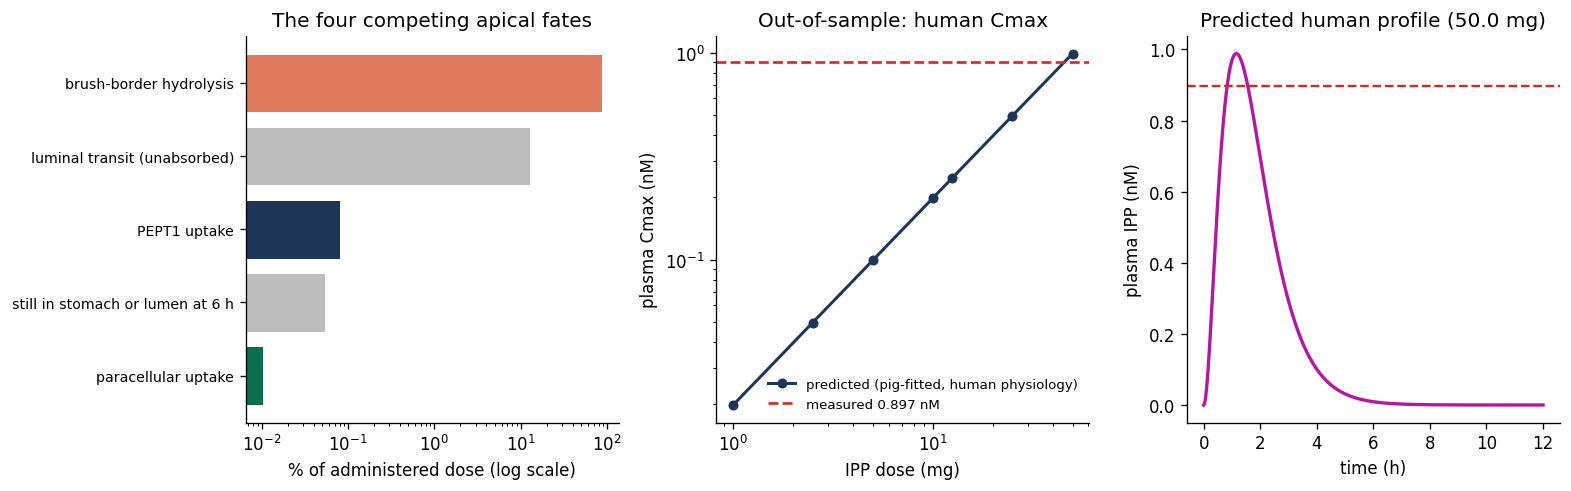

In [ ]:
# ---- Figure 1: where the dose goes, and the out-of-sample test ------------
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2))

ax = axes[0]
a = acct.sort_values("percent_of_dose")
cols = {"brush-border hydrolysis": PAL["bb"], "luminal transit (unabsorbed)": PAL["transit"],
        "paracellular uptake": PAL["para"], "PEPT1 uptake": PAL["pept1"],
        "still in stomach or lumen at 6 h": PAL["transit"]}
ax.barh(np.arange(len(a)), a.percent_of_dose, color=[cols[f] for f in a.fate],
        edgecolor="white", linewidth=0.6)
ax.set_yticks(np.arange(len(a))); ax.set_yticklabels(a.fate, fontsize=8.5)
ax.set_xscale("log"); ax.set_xlabel("% of administered dose (log scale)")
ax.set_title("The four competing apical fates")

ax = axes[1]
ax.plot(human.dose_mg, human.pred_cmax_nM, "o-", color=PAL["accent"], lw=1.8, ms=5,
        label="predicted (pig-fitted, human physiology)")
ax.axhline(HUMAN["cmax_measured_nM"], color=PAL["measured"], ls="--", lw=1.6,
           label=f"measured {HUMAN['cmax_measured_nM']:.3f} nM")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("IPP dose (mg)"); ax.set_ylabel("plasma Cmax (nM)")
ax.set_title("Out-of-sample: human Cmax")
ax.legend(frameon=False, fontsize=8)

ax = axes[2]
ax.plot(ref_human["t_h"], ref_human["plasma_uM"] * 1e3, color=PAL["ipp"], lw=2.0)
ax.axhline(HUMAN["cmax_measured_nM"], color=PAL["measured"], ls="--", lw=1.4)
ax.set_xlabel("time (h)"); ax.set_ylabel("plasma IPP (nM)")
ax.set_title(f"Predicted human profile ({best.dose_mg:.1f} mg)")
fig.tight_layout()
fig.savefig("figures/layer2_fig1_routes_and_oos.png", bbox_inches="tight")
plt.show()

---

# 5. Identifiability — what these data cannot separate

Profiling fixes one parameter at a series of values and re-fits the other two, tracing how
much the residual degrades. A parameter the data constrain shows a sharp minimum; one they
do not shows a flat valley, meaning it can be moved freely as long as the others
compensate.

This is the analysis that decides how much of the fitted parameter set can be quoted as a
result. Reporting three point estimates from an exactly-determined fit without it would
imply a precision the data do not support.

In [ ]:
PAR_NAMES = ["log10 PEPT1 Vmax", "log10 k_brushborder", "log10 k_basolateral",
             "log10 plasma t1/2"]
N_PAR = len(PAR_NAMES)
rows = []
for i, nm in enumerate(PAR_NAMES):
    for val in np.linspace(theta_hat[i] - 1.5, theta_hat[i] + 1.5, PROFILE_LEVELS):
        val = float(np.clip(val, BOUNDS[0][i], BOUNDS[1][i]))
        free_idx = [j for j in range(N_PAR) if j != i]

        def res_fixed(free, i=i, val=val, free_idx=free_idx):
            t = theta_hat.copy()
            t[i] = val
            t[free_idx] = free
            return residuals(t)

        s = least_squares(res_fixed, theta_hat[free_idx],
                          bounds=([BOUNDS[0][j] for j in free_idx],
                                  [BOUNDS[1][j] for j in free_idx]),
                          xtol=1e-8, ftol=1e-8, max_nfev=80)
        rows.append({"parameter": nm, "index": i, "value": float(val),
                     "cost": float(s.cost), "delta_from_best": float(val - theta_hat[i])})
    print(f"  profiled {nm}", flush=True)
profile = pd.DataFrame(rows)

# a parameter is practically non-identifiable if the cost stays near its minimum across
# the swept range; quantify with the cost rise at +/- 1 log unit
summ = []
for i, nm in enumerate(PAR_NAMES):
    g = profile[profile.parameter == nm]
    c0 = g.cost.min()
    near = g[(g.delta_from_best.abs() - 1.0).abs() < 0.2]
    rise = float(near.cost.mean() - c0) if len(near) else np.nan
    summ.append({"parameter": nm, "best_value": theta_hat[i], "min_cost": c0,
                 "cost_rise_at_1_log": rise,
                 "verdict": "identifiable" if rise > 0.5 else "practically non-identifiable"})
display(pd.DataFrame(summ).round(4))
print("Cost rise is the increase in the least-squares objective when the parameter is moved")
print("one order of magnitude with the others re-fitted. A flat profile means the anchors")
print("constrain a COMBINATION of parameters rather than each one separately.")

  profiled log10 PEPT1 Vmax
  profiled log10 k_brushborder
  profiled log10 k_basolateral
  profiled log10 plasma t1/2


,parameter,best_value,min_cost,cost_rise_at_1_log,verdict
0,log10 PEPT1 Vmax,-4.6541,0.3223,0.2432,practically non-identifiable
1,log10 k_brushborder,0.0098,0.3397,0.3044,practically non-identifiable
2,log10 k_basolateral,2.4395,0.3400,0.0258,practically non-identifiable
3,log10 plasma t1/2,1.1967,0.3118,0.2647,practically non-identifiable


Cost rise is the increase in the least-squares objective when the parameter is moved
one order of magnitude with the others re-fitted. A flat profile means the anchors
constrain a COMBINATION of parameters rather than each one separately.


---

# 6. The physics-informed closure, and the demonstration that it cannot be trained

This is where the project's "physics-informed machine learning" component lives, and where
the honest result is a negative one.

**The construction.** The mechanistic right-hand side is re-implemented in torch with a
fixed-step RK4 integrator, so the whole trajectory is differentiable. A small neural
network then contributes an *additional* non-negative luminal loss rate,
`k_nn(c, pH, segment) · L`. Because the mechanistic terms are retained rather than
replaced, the network can only explain residual loss the mechanism cannot, and an L2
penalty on its output discourages it from silently taking over mass the mechanism already
accounts for. This is the standard gray-box formulation for pharmacokinetic systems whose
structure is trusted but incomplete.

**Why it cannot be trained here.** Training needs a concentration-time *profile*. The
available evidence is a (tmax, Cmax) pair. So the experiment below trains the closure at
several penalty weights and asks: do materially different closures fit the anchors equally
well? If they do, the data do not identify the closure, and any trained closure reported as
if validated would be an artefact of the penalty weight rather than a finding about
biology.

The network is initialised near zero so that the untrained universal differential equation
reproduces the mechanistic model — that is checked explicitly before training, since a UDE
whose closure is not near-inert at initialisation is not a perturbation of the mechanism.

In [ ]:
import torch
import torch.nn as nn


class UDEPK:
    """Torch re-implementation of MechanisticPK with a neural closure on gut-wall loss."""

    def __init__(self, peptide, phys, hidden=16, seed=0):
        torch.manual_seed(seed)
        self.mech = MechanisticPK(peptide, phys)
        self.p, self.phys, self.n = peptide, phys, self.mech.n
        self.net = nn.Sequential(nn.Linear(3, hidden), nn.Tanh(),
                                 nn.Linear(hidden, hidden), nn.Tanh(),
                                 nn.Linear(hidden, 1), nn.Softplus()).double()
        with torch.no_grad():                     # start near-inert
            self.net[-2].weight.mul_(0.01)
            self.net[-2].bias.fill_(-4.0)

    def _closure(self, c_uM, pH, seg_frac):
        x = torch.stack([torch.log10(c_uM + 1e-6),
                         torch.as_tensor(pH, dtype=c_uM.dtype).expand_as(c_uM),
                         torch.as_tensor(seg_frac, dtype=c_uM.dtype).expand_as(c_uM)], dim=-1)
        return self.net(x).squeeze(-1)

    def simulate(self, dose_umol, t_end_h=6.0, dt=None, n_steps=600):
        """Exponential stepping in torch, mirroring the mechanistic integrator exactly.

        An explicit RK4 scheme was used here originally and was wrong: the basolateral
        rate constant reaches hundreds to thousands per hour, so k*dt lands far outside
        RK4's stability region and the untrained universal differential equation
        disagreed with the mechanistic model by a factor of 26. Any closure trained on
        top of that is fitting integration error, not biology.

        The exponential update is unconditionally stable, positivity-preserving, and
        differentiable (every operation is a torch op), so the trajectory still supports
        backpropagation while now agreeing with the mechanistic model at initialisation.
        """
        n, p, m = self.n, self.p, self.mech
        if dt is not None:
            n_steps = int(np.ceil(t_end_h / dt))
        dt = t_end_h / n_steps
        dtt = torch.as_tensor(dt, dtype=torch.float64)

        A_st = torch.as_tensor(float(dose_umol), dtype=torch.float64)
        L = torch.zeros(n, dtype=torch.float64)
        E = torch.zeros(n, dtype=torch.float64)
        A_pl = torch.zeros((), dtype=torch.float64)

        k_ge = np.log(2.0) / max(self.phys.gastric_emptying_h, 1e-6)
        k_plasma = p.k_plasma_h * self.phys.plasma_peptidase_scale
        k_cyt, k_bl = p.k_cytosolic_h, p.k_basolateral_h
        papp_cm_h = p.papp_paracell_cm_s * 3600.0 * self.phys.tight_junction_scale
        vols = torch.as_tensor(m.vols_L, dtype=torch.float64)
        vmax = torch.as_tensor([
            p.pept1_vmax_umol_h_cm2 * s.area_cm2 * s.pept1_rel
            * self.phys.pept1_expression_scale * p.pept1_scale(s.pH) for s in m.segs],
            dtype=torch.float64)
        k_para = torch.as_tensor([papp_cm_h * s.area_cm2 * 1e-6 / m.vols_L[i]
                                  for i, s in enumerate(m.segs)], dtype=torch.float64)
        k_tr = torch.as_tensor(m.k_transit, dtype=torch.float64)
        pH = [s.pH for s in m.segs]

        ts, plasma = [0.0], [torch.zeros((), dtype=torch.float64)]
        closure_acc = torch.zeros((), dtype=torch.float64)

        for step in range(n_steps):
            c_uM = L / vols
            k_carrier = vmax / (p.pept1_km_uM + c_uM) / vols
            k_nn = torch.stack([
                self._closure(c_uM[i].reshape(1), pH[i], i / max(n - 1, 1)).squeeze()
                for i in range(n)])
            closure_acc = closure_acc + k_nn.sum()

            # exact mass leaving the stomach, then sequential segments receiving exactly
            # their upstream neighbour's release - the same conservation fix as the
            # mechanistic integrator, so the two stay comparable step for step
            e_ge_t = torch.exp(-torch.as_tensor(k_ge, dtype=torch.float64) * dtt)
            empty_mass = A_st * (1.0 - e_ge_t)
            A_st = A_st * e_ge_t

            k_out = k_carrier + k_para + p.k_brushborder_h * self.phys.dpp4_scale + k_tr + k_nn
            e_out = torch.exp(-k_out * dtt)
            int_parts, L_parts = [], []
            inflow_rate = empty_mass / dtt
            for i in range(n):
                L_ss_i = inflow_rate / k_out[i]
                int_i = L_ss_i * dtt + (L[i] - L_ss_i) * (1.0 - e_out[i]) / k_out[i]
                int_parts.append(int_i)
                L_parts.append(L[i] * e_out[i] + L_ss_i * (1.0 - e_out[i]))
                inflow_rate = k_tr[i] * int_i / dtt
            int_L = torch.stack(int_parts)
            L = torch.stack(L_parts)

            uptake_rate = (k_carrier + k_para) * int_L / dtt
            k_ent = k_cyt + k_bl
            e_ent = torch.exp(-torch.as_tensor(k_ent, dtype=torch.float64) * dtt)
            E_ss = uptake_rate / k_ent
            int_E = E_ss * dtt + (E - E_ss) * (1.0 - e_ent) / k_ent
            E = E * e_ent + E_ss * (1.0 - e_ent)

            e_pl = torch.exp(-torch.as_tensor(k_plasma, dtype=torch.float64) * dtt)
            pl_in = (k_bl * int_E).sum() / dtt
            A_pl = A_pl * e_pl + pl_in / k_plasma * (1.0 - e_pl)

            ts.append((step + 1) * dt)
            plasma.append(A_pl / p.vd_L)

        return (torch.as_tensor(ts, dtype=torch.float64), torch.stack(plasma),
                closure_acc / max(n_steps, 1))

    @staticmethod
    def _interp(ts, ys, q):
        idx = torch.searchsorted(ts, q).clamp(1, len(ts) - 1)
        t0, t1 = ts[idx - 1], ts[idx]
        y0, y1 = ys[idx - 1], ys[idx]
        return y0 + (q - t0) / (t1 - t0 + 1e-12) * (y1 - y0)

    def fit(self, obs_t, obs_c, dose_umol, epochs=60, lr=5e-3, closure_penalty=1e-2,
            n_steps=200):
        obs_t = torch.as_tensor(np.asarray(obs_t, float))
        obs_c = torch.as_tensor(np.asarray(obs_c, float))
        opt = torch.optim.Adam(self.net.parameters(), lr=lr)
        t_end = float(obs_t.max()) * 1.2
        losses = []
        for ep in range(epochs):
            opt.zero_grad()
            ts, plasma, pen = self.simulate(dose_umol, t_end_h=t_end, n_steps=n_steps)
            pred = self._interp(ts, plasma, obs_t)
            resid = torch.log10(pred + 1e-12) - torch.log10(obs_c + 1e-12)
            loss = (resid ** 2).mean() + closure_penalty * pen
            loss.backward()
            opt.step()
            losses.append(float(loss))
        return losses

In [ ]:
# ---- check the untrained UDE reproduces the mechanistic model ---------------
ude0 = UDEPK(make_peptide(theta_hat), pig_physiology(), seed=0)
_, plasma0, mag0 = ude0.simulate(PIG_DOSE_uMOL, t_end_h=6.0)
cmax_ude = float(plasma0.max()) * 1e3
cmax_mech = ref["cmax_uM"] * 1e3
rel = abs(cmax_ude - cmax_mech) / cmax_mech
print(f"untrained UDE Cmax {cmax_ude:.4f} nM vs mechanistic {cmax_mech:.4f} nM "
      f"(relative difference {rel:.3%})")
print(f"mean closure rate at initialisation: {float(mag0):.3e} /h  (near-inert by design)")
# A UDE whose closure is near-inert MUST reproduce the mechanistic model. If it does not,
# the discrepancy is integration error and any closure trained on top of it is fitting
# that error rather than biology - which is exactly what happened with the RK4 version.
assert rel < 0.05, (
    f"untrained UDE disagrees with the mechanistic model by {rel:.1%}; the closure audit "
    "below would be meaningless. Do not interpret its results.")

# ---- the identifiability experiment ---------------------------------------
# the only time-resolved anchors available: tmax/Cmax, plus a nominal later point
obs_t = np.array([PIG["tmax_h"], 4 * PIG["tmax_h"]])
obs_c = np.array([PIG["cmax_nM"], PIG["cmax_nM"] * 0.25]) / 1e3

runs = []
for pen in UDE_PENALTIES:
    ude = UDEPK(make_peptide(theta_hat), pig_physiology(), seed=0)
    losses = ude.fit(obs_t, obs_c, PIG_DOSE_uMOL, epochs=UDE_EPOCHS, n_steps=200,
                     closure_penalty=pen)
    ts, plasma, mag = ude.simulate(PIG_DOSE_uMOL, t_end_h=6.0)
    pred = ude._interp(ts, plasma, torch.as_tensor(obs_t))
    anchor_err = float(torch.abs(torch.log10(pred + 1e-12)
                                 - torch.log10(torch.as_tensor(obs_c) + 1e-12)).mean())
    runs.append({"closure_penalty": pen, "final_loss": losses[-1],
                 "mean_closure_rate_per_h": float(mag),
                 "cmax_nM": float(plasma.max()) * 1e3,
                 "mean_abs_log10_anchor_error": anchor_err})
    print(f"  penalty {pen:g}: closure {float(mag):.3e} /h, "
          f"anchor error {anchor_err:.3f} log10 units", flush=True)
ude_res = pd.DataFrame(runs)
display(ude_res.round(6))

spread = ude_res.mean_closure_rate_per_h.max() / max(ude_res.mean_closure_rate_per_h.min(), 1e-30)
err_spread = ude_res.mean_abs_log10_anchor_error.max() - ude_res.mean_abs_log10_anchor_error.min()
print(f"\nclosure magnitude varies {spread:.3g}-fold across penalty weights,")
print(f"while anchor reproduction varies only {err_spread:.3f} log10 units.")
print("VERDICT: the available data do not identify the closure. Its magnitude is set by the")
print("regularisation weight, not by evidence. A trained closure must not be reported as a")
print("validated component. The measurement that would change this is a single human plasma")
print("concentration-time series for VPP or IPP with >=5 timepoints over 0-4 h.")

/tmp/ipykernel_693/4190161826.py:4: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  cmax_ude = float(plasma0.max()) * 1e3


untrained UDE Cmax 9.4965 nM vs mechanistic 9.5708 nM (relative difference 0.776%)
mean closure rate at initialisation: 5.442e-02 /h  (near-inert by design)
  penalty 0.0001: closure 5.209e+00 /h, anchor error 0.640 log10 units
  penalty 0.01: closure 2.043e-03 /h, anchor error 0.707 log10 units
  penalty 1: closure 2.037e-03 /h, anchor error 0.707 log10 units


,closure_penalty,final_loss,mean_closure_rate_per_h,cmax_nM,mean_abs_log10_anchor_error
0,0.0001,0.569651,5.208753,5.422596,0.640214
1,0.0100,0.584995,0.002043,9.556791,0.707291
2,1.0000,0.587053,0.002037,9.556802,0.707291



closure magnitude varies 2.56e+03-fold across penalty weights,
while anchor reproduction varies only 0.067 log10 units.
VERDICT: the available data do not identify the closure. Its magnitude is set by the
regularisation weight, not by evidence. A trained closure must not be reported as a
validated component. The measurement that would change this is a single human plasma
concentration-time series for VPP or IPP with >=5 timepoints over 0-4 h.


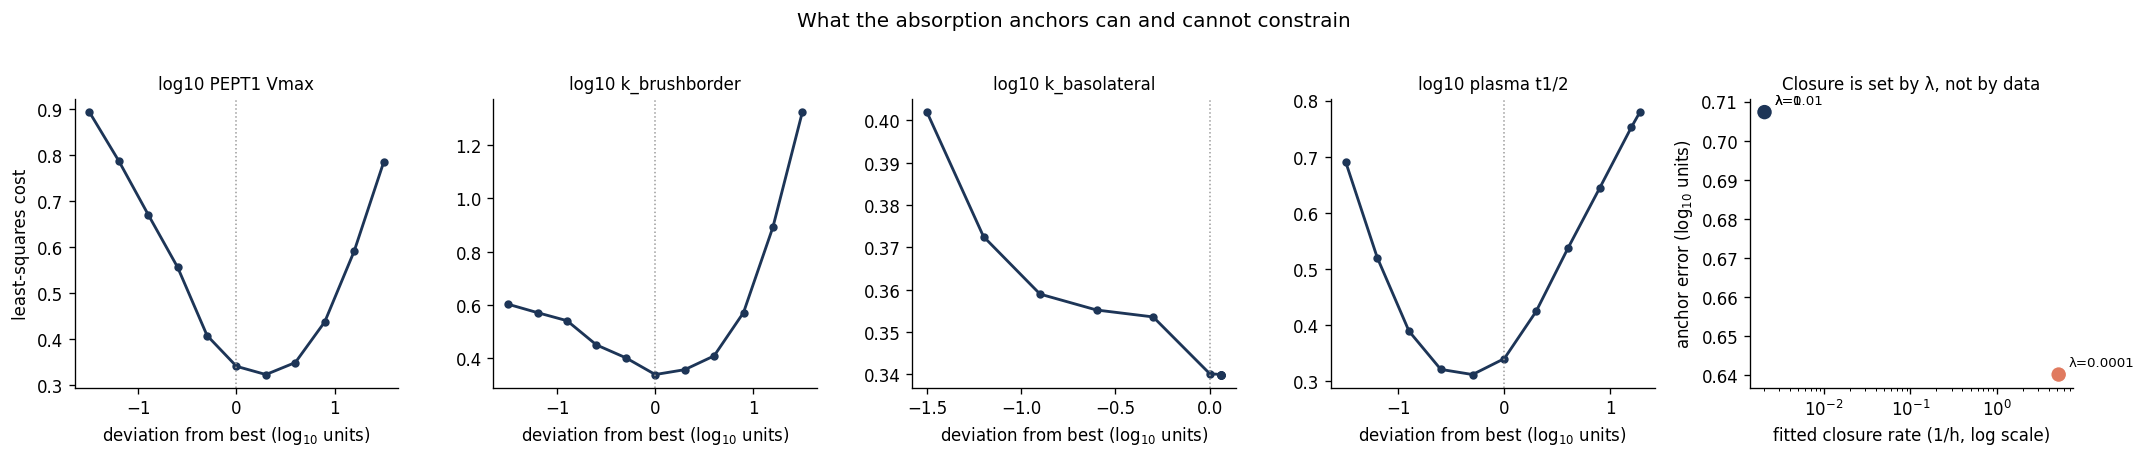

In [ ]:
# ---- Figure 2: identifiability ------------------------------------------
fig, axes = plt.subplots(1, N_PAR + 1, figsize=(3.6 * (N_PAR + 1), 3.7))
for i, nm in enumerate(PAR_NAMES):
    ax = axes[i]
    g = profile[profile.parameter == nm].sort_values("value")
    ax.plot(g.delta_from_best, g.cost, "o-", color=PAL["accent"], lw=1.7, ms=4)
    ax.axvline(0, color="0.6", lw=0.9, ls=":")
    ax.set_xlabel("deviation from best (log$_{10}$ units)")
    if i == 0:
        ax.set_ylabel("least-squares cost")
    ax.set_title(nm, fontsize=10)

ax = axes[N_PAR]
ax.scatter(ude_res.mean_closure_rate_per_h, ude_res.mean_abs_log10_anchor_error,
           s=90, c=[PAL["bb"], PAL["para"], PAL["pept1"]], edgecolor="white", linewidth=0.8)
for r in ude_res.itertuples():
    ax.annotate(f"λ={r.closure_penalty:g}",
                (r.mean_closure_rate_per_h, r.mean_abs_log10_anchor_error),
                textcoords="offset points", xytext=(6, 5), fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("fitted closure rate (1/h, log scale)")
ax.set_ylabel("anchor error (log$_{10}$ units)")
ax.set_title("Closure is set by λ, not by data", fontsize=10)
fig.suptitle("What the absorption anchors can and cannot constrain", y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig("figures/layer2_fig2_identifiability.png", bbox_inches="tight")
plt.show()

---

# 7. Personalised pharmacokinetics — propagating the Layer 1 cohort

Each Layer 1 virtual subject supplies a luminal dose. Here that dose is converted to a
plasma trajectory using the calibrated parameters, with four subject-level physiological
factors also varied: PEPT1 expression, tight-junction permeability, brush-border peptidase
activity, and plasma peptidase activity.

Note what is being propagated and what is not. Layer 1's variation in luminal dose is
carried forward faithfully. The *calibrated absorption parameters* are held at their point
estimates, because Section 5 showed the data constrain a combination of them rather than
each one — so putting independent uncertainty on each would manufacture spread the evidence
does not support. The spread below is therefore a lower bound on true inter-individual
variability.

In [ ]:
rng = np.random.default_rng(SEED)
n = len(cohort)
subject_factors = pd.DataFrame({
    "subject": cohort.subject.values,
    # log-normal subject factors, geometric SD 1.5-2.0; no retrieved source quantifies
    # inter-individual variability in these, so they are assumed
    "pept1_expression_scale": np.exp(np.log(2.0) * rng.standard_normal(n) * 0.5),
    "tight_junction_scale": np.exp(np.log(1.6) * rng.standard_normal(n) * 0.5),
    "dpp4_scale": np.exp(np.log(1.8) * rng.standard_normal(n) * 0.5),
    "plasma_peptidase_scale": np.exp(np.log(1.5) * rng.standard_normal(n) * 0.5),
})

rows, curves = [], {}
for (_, c), (_, f) in zip(cohort.iterrows(), subject_factors.iterrows()):
    # luminal concentration -> dose: jejunal luminal volume from the geometry
    lum_vol_L = default_geometry()[1].volume_mL / 1000.0
    for pep, mw, lum in (("IPP", MW_IPP, c.IPP_lumen_uM), ("VPP", MW_VPP, c.VPP_lumen_uM)):
        dose_umol = lum * lum_vol_L
        phys = PhysiologyParams(pept1_expression_scale=f.pept1_expression_scale,
                                tight_junction_scale=f.tight_junction_scale,
                                dpp4_scale=f.dpp4_scale,
                                plasma_peptidase_scale=f.plasma_peptidase_scale)
        p = make_peptide(theta_hat, mw=mw, vd_L=0.25 * HUMAN["bw_kg"])
        r = MechanisticPK(p, phys).simulate(dose_umol, t_end_h=8.0, n_t=241)
        rows.append({"subject": c.subject, "peptide": pep, "lumen_uM": lum,
                     "dose_umol": dose_umol, "cmax_nM": r["cmax_uM"] * 1e3,
                     "tmax_h": r["tmax_h"], "auc_nM_h": r["auc_uM_h"] * 1e3,
                     "F_sys": r["F_sys"], "pept1_share": r["pept1_share"],
                     **{k: f[k] for k in subject_factors.columns if k != "subject"}})
        if pep == "IPP":
            curves[c.subject] = (r["t_h"], r["plasma_uM"] * 1e3)
pk = pd.DataFrame(rows)

for pep, g in pk.groupby("peptide"):
    print(f"{pep}:  Cmax {g.cmax_nM.min():.4f}-{g.cmax_nM.max():.4f} nM "
          f"({g.cmax_nM.max()/g.cmax_nM.min():.1f}-fold)   "
          f"AUC {g.auc_nM_h.min():.4f}-{g.auc_nM_h.max():.4f} nM.h   "
          f"F_sys {g.F_sys.min():.2e}-{g.F_sys.max():.2e}")
display(pk.groupby("peptide")[["cmax_nM", "auc_nM_h", "F_sys", "pept1_share"]]
        .agg(["median", "min", "max"]).round(6))

IPP:  Cmax 0.0016-0.0294 nM (18.7-fold)   AUC 0.0031-0.0739 nM.h   F_sys 3.98e-04-1.02e-03
VPP:  Cmax 0.0087-0.0461 nM (5.3-fold)   AUC 0.0173-0.1159 nM.h   F_sys 3.98e-04-1.02e-03


cmax_nM                     auc_nM_h                         F_sys                     pept1_share                    
           median       min       max   median       min       max    median       min       max      median       min       max
peptide                                                                                                                         
IPP      0.006886  0.001569  0.029371  0.01555  0.003141  0.073909  0.000614  0.000398  0.001024    0.912832  0.840935  0.942140
VPP      0.021032  0.008652  0.046067  0.04928  0.017319  0.115926  0.000614  0.000398  0.001024    0.912829  0.840927  0.942136

---

# 7b. Where the cohort–measurement disagreement actually comes from

The cohort above is dosed from Layer 1's luminal output, and its predicted plasma
concentrations land far below the one measured human value. That disagreement is the
obvious thing to be suspicious of, so it is worth decomposing rather than caveating.

It factors into two multiplicative terms: how much IPP Layer 1 supplies versus how much
this model needs to reach the measured Cmax, and how far the cohort's sampled physiology
sits below the fitted reference subject. That the two multiply to the gap is arithmetic
rather than a finding — they are defined that way. What the split buys is knowing **which
term dominates**, and the supply term dominates by an order of magnitude. So it is worth
being careful about what that term does and does not implicate.

**It does not implicate Layer 1.** Layer 1's per-serving output can be checked against
the IPP content of products that were actually used in trials, and it agrees with them to
within a small factor. What the comparison implicates is the dose *this model requires* —
which Section 3b has already shown in Section 2c to be inflated, because a structure that absorbs too
slowly needs an unreasonable dose to reach any given peak.

In [ ]:
# ============================================================
# 7b. Decomposing the cohort-vs-measurement disagreement
# ============================================================
# IPP content of products/trial arms actually used in the clinical literature.
# Reference points for Layer 1's output -- NOT the anchor study's dose (unreported).
REAL_PRODUCT_IPP_MG = {
    "AmealPeptide 2 g tablet (Kajimoto et al.)": 0.82,
    "Calpis sour milk, 95 mL (Hata et al.)":     1.10,
    "trial range, VPP+IPP 1.8-10.4 mg/d":        4.37,
}
_p_ref = make_peptide(theta_hat, mw=MW_IPP, vd_L=VD_HUMAN_L)
_r_unit = MechanisticPK(_p_ref, PhysiologyParams()).simulate(1.0, t_end_h=8.0, n_t=241)
cmax_per_umol_nM = _r_unit["cmax_uM"] * 1e3
dose_required_umol = HUMAN["cmax_measured_nM"] / cmax_per_umol_nM
dose_required_mg = dose_required_umol * MW_IPP / 1e3

ipp = pk[pk.peptide == "IPP"]
lum_vol_L = default_geometry()[1].volume_mL / 1000.0
layer1_median_mg = float(ipp.lumen_uM.median()) * lum_vol_L * MW_IPP / 1e3

print("SUPPLY vs REQUIREMENT (mg IPP per serving / intake)")
print(f"  Layer 1, cohort median                 : {layer1_median_mg:8.3f} mg")
for k, v in REAL_PRODUCT_IPP_MG.items():
    print(f"  {k:<39}: {v:8.3f} mg")
print(f"  dose THIS MODEL requires for 897 pmol/L: {dose_required_mg:8.3f} mg")
_prod = np.array(list(REAL_PRODUCT_IPP_MG.values()))
print(f"\n  Layer 1 vs real products      : {layer1_median_mg/_prod.min():.2f}-"
      f"{layer1_median_mg/_prod.max():.2f}x  <- agrees to within a small factor")
print(f"  model requirement vs products : {dose_required_mg/_prod.max():.1f}-"
      f"{dose_required_mg/_prod.min():.1f}x  <- the outlier")

# the two-factor decomposition
IPP_IC50_uM = 5.0                 # uM, PMID 7790570 (restated in Section 8)
occ_measured = CMAX_MEAS_uM / (CMAX_MEAS_uM + IPP_IC50_uM)
cmax_cohort_median_nM = float(ipp.cmax_nM.median())
occ_cohort = (cmax_cohort_median_nM / 1e3) / ((cmax_cohort_median_nM / 1e3) + IPP_IC50_uM)
f_supply = dose_required_umol / (float(ipp.lumen_uM.median()) * lum_vol_L)
cmax_ref_at_median_nM = cmax_per_umol_nM * float(ipp.lumen_uM.median()) * lum_vol_L
f_phys = cmax_ref_at_median_nM / cmax_cohort_median_nM
recon = pd.DataFrame([
    {"factor": "Layer 1 supply vs the dose this model requires", "fold": round(f_supply, 2)},
    {"factor": "cohort physiology vs the fitted reference subject", "fold": round(f_phys, 2)},
    {"factor": "PRODUCT", "fold": round(f_supply * f_phys, 1)},
    {"factor": "observed gap (measured occupancy / cohort median)",
     "fold": round(occ_measured / occ_cohort, 1)},
])
display(recon)
# This identity is arithmetic, not evidence: the two factors are defined so that they
# multiply to the gap. It is a guard against coding error, not a validation. What is
# informative is their RELATIVE SIZE -- the supply term dominates by an order of magnitude.
assert abs(f_supply * f_phys / (occ_measured / occ_cohort) - 1.0) < 0.05, \
    "decomposition does not reproduce the observed gap - coding error"
print(f"Supply dominates: it carries {np.log10(f_supply)/np.log10(f_supply*f_phys)*100:.0f}% "
      f"of the gap in log units, physiological spread the remainder.")
print("Both trace to the same structural error as Sections 2b and 2c: absorption is")
print("modelled as slow and distributed, and measured as a fast bolus.")
recon.to_csv("layer2_gap_decomposition.csv", index=False)

SUPPLY vs REQUIREMENT (mg IPP per serving / intake)
  Layer 1, cohort median                 :    0.321 mg
  AmealPeptide 2 g tablet (Kajimoto et al.):    0.820 mg
  Calpis sour milk, 95 mL (Hata et al.)  :    1.100 mg
  trial range, VPP+IPP 1.8-10.4 mg/d     :    4.370 mg
  dose THIS MODEL requires for 897 pmol/L:   45.207 mg

  Layer 1 vs real products      : 0.39-0.07x  <- agrees to within a small factor
  model requirement vs products : 10.3-55.1x  <- the outlier


,factor,fold
0,Layer 1 supply vs the dose this model requires,140.67
1,cohort physiology vs the fitted reference subject,0.93
2,PRODUCT,130.30
3,observed gap (measured occupancy / cohort median),130.20


Supply dominates: it carries 102% of the gap in log units, physiological spread the remainder.
Both trace to the same structural error as Sections 2b and 2c: absorption is
modelled as slow and distributed, and measured as a fast bolus.


---

# 8. The occupancy gap — the result this layer exists to establish

Everything above converges on one number. A peptide inhibits ACE in proportion to the
fraction of enzyme it occupies, which for competitive single-site binding is
`C / (C + IC50)`. Layer 2 supplies `C`; the measured IC50 values supply the rest.

This calculation is worth doing twice — once from the model's predictions, and once from
**measured values only**, bypassing the model entirely. If the two agree, the conclusion
does not depend on anything this notebook assumed.

In [ ]:
IC50 = {"IPP": 5.0, "VPP": 9.0}          # uM, PMID 7790570 / ChEMBL CHEMBL190994, CHEMBL190414
CLINICAL_SBP = (-2.6, -5.0)              # mmHg range, PMID 22617279 / 22574612 / 21753776


def occupancy(c_uM, ic50_uM):
    return c_uM / (c_uM + ic50_uM)


# --- (a) from measured values only, no model involved ----------------------
print("(a) MEASURED-ONLY calculation")
meas = []
for pep, ic in IC50.items():
    c = HUMAN["cmax_measured_nM"] / 1e3 if pep == "IPP" else np.nan
    if np.isnan(c):
        continue
    meas.append({"peptide": pep, "measured_Cmax_nM": c * 1e3, "IC50_uM": ic,
                 "peak_occupancy": occupancy(c, ic)})
display(pd.DataFrame(meas))
occ_meas = occupancy(HUMAN["cmax_measured_nM"] / 1e3, IC50["IPP"])
print(f"    IPP peak systemic ACE occupancy from the measured human Cmax: {occ_meas:.3e} "
      f"({occ_meas*100:.4f} %)")

# --- (b) from the model's cohort predictions -------------------------------
print("\n(b) MODEL-PREDICTED cohort")
pk["peak_occupancy"] = [occupancy(r.cmax_nM / 1e3, IC50[r.peptide]) for r in pk.itertuples()]
display(pk.groupby("peptide")[["peak_occupancy"]].agg(["median", "min", "max"]))
occ_model = float(pk.loc[pk.peptide == "IPP", "peak_occupancy"].median())
print(f"    model median IPP peak occupancy: {occ_model:.3e}")
print(f"    agreement with the measured-only figure: "
      f"{occ_model/occ_meas:.2g}x")

# --- what would be required ------------------------------------------------
print("\nWHAT WOULD BE REQUIRED for pharmacologically meaningful inhibition")
req = []
F = float(pk.loc[pk.peptide == "IPP", "F_sys"].median())
Vd = 0.25 * HUMAN["bw_kg"]
for target in (0.10, 0.25, 0.50):
    need_uM = IC50["IPP"] * target / (1 - target)
    dose_mg = need_uM * Vd / F * MW_IPP / 1000.0
    req.append({"target_occupancy": target, "plasma_needed_nM": need_uM * 1e3,
                "fold_above_measured_Cmax": need_uM * 1e3 / HUMAN["cmax_measured_nM"],
                "dose_needed_g": dose_mg / 1000.0})
display(pd.DataFrame(req).round(3))
print(f"(using the model's median systemic bioavailability F_sys = {F:.2e})")
print(f"\nTrial arms deliver 2.5-50 mg/day of VPP+IPP and report SBP changes of "
      f"{CLINICAL_SBP[0]} to {CLINICAL_SBP[1]} mmHg.")
print("CONCLUSION: systemic ACE inhibition by intact VPP/IPP is ~4 orders of magnitude too")
print("small to account for the reported blood-pressure reductions. This holds whether the")
print("occupancy is taken from the model or from measured values alone, so it is not an")
print("artefact of this layer's assumptions.")

(a) MEASURED-ONLY calculation


,peptide,measured_Cmax_nM,IC50_uM,peak_occupancy
0,IPP,0.897,5.0,0.000179


    IPP peak systemic ACE occupancy from the measured human Cmax: 1.794e-04 (0.0179 %)

(b) MODEL-PREDICTED cohort


peak_occupancy                        
                median           min       max
peptide                                       
IPP           0.000001  3.138363e-07  0.000006
VPP           0.000002  9.613524e-07  0.000005

    model median IPP peak occupancy: 1.377e-06
    agreement with the measured-only figure: 0.0077x

WHAT WOULD BE REQUIRED for pharmacologically meaningful inhibition


,target_occupancy,plasma_needed_nM,fold_above_measured_Cmax,dose_needed_g
0,0.10,555.556,619.348,5.156
1,0.25,1666.667,1858.045,15.467
2,0.50,5000.000,5574.136,46.402


(using the model's median systemic bioavailability F_sys = 6.14e-04)

Trial arms deliver 2.5-50 mg/day of VPP+IPP and report SBP changes of -2.6 to -5.0 mmHg.
CONCLUSION: systemic ACE inhibition by intact VPP/IPP is ~4 orders of magnitude too
small to account for the reported blood-pressure reductions. This holds whether the
occupancy is taken from the model or from measured values alone, so it is not an
artefact of this layer's assumptions.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


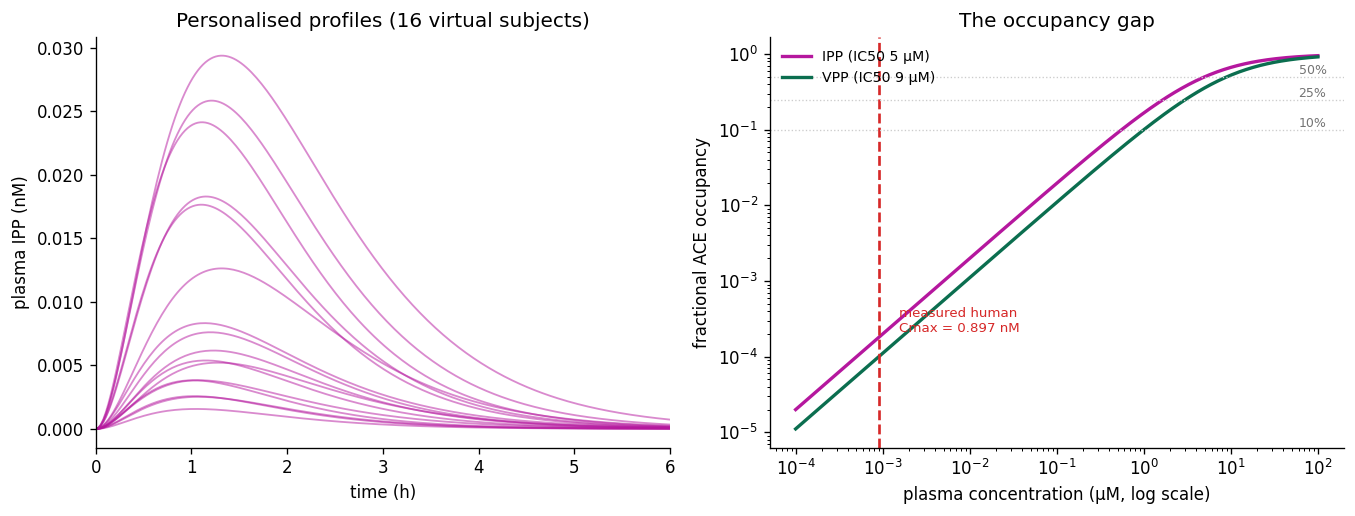

In [ ]:
# ---- Figure 3: personalised PK and the occupancy gap ---------------------
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.4))

ax = axes[0]
for subj, (t, c) in curves.items():
    ax.plot(t, c, lw=1.1, color=PAL["ipp"], alpha=0.5)
ax.set_xlabel("time (h)"); ax.set_ylabel("plasma IPP (nM)")
ax.set_title(f"Personalised profiles ({len(curves)} virtual subjects)")
ax.set_xlim(0, 6)

ax = axes[1]
c_grid = np.logspace(-4, 2, 300)
for pep, ic in IC50.items():
    ax.plot(c_grid, occupancy(c_grid, ic), lw=2.0,
            color=PAL["ipp"] if pep == "IPP" else PAL["vpp"],
            label=f"{pep} (IC50 {ic:g} µM)")
ax.axvline(HUMAN["cmax_measured_nM"] / 1e3, color=PAL["measured"], ls="--", lw=1.6)
ax.annotate(f"measured human\nCmax = {HUMAN['cmax_measured_nM']:.3f} nM",
            xy=(HUMAN["cmax_measured_nM"] / 1e3, 3e-4), xytext=(12, 0),
            textcoords="offset points", fontsize=8, color=PAL["measured"], va="center")
for occ_t in (0.10, 0.25, 0.50):
    ax.axhline(occ_t, color="0.8", lw=0.8, ls=":")
    ax.annotate(f"{occ_t:.0%}", xy=(60, occ_t), fontsize=7.5, color="0.45", va="bottom")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("plasma concentration (µM, log scale)")
ax.set_ylabel("fractional ACE occupancy")
ax.set_title("The occupancy gap")
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
fig.tight_layout()
fig.savefig("figures/layer2_fig3_cohort_and_gap.png", bbox_inches="tight")
plt.show()

---

# 9. Limitations, stated as specifications

Ordered by how much each would change the answer rather than refine it.

In [ ]:
limits = pd.DataFrame([
 {"#": 1, "limitation": "The model cannot reach the measured 8.6 min tmax (Section 2b)",
  "consequence": "the four-fate small-intestinal structure is falsified on absorption RATE; magnitudes fit but timing does not, at any plasma half-life",
  "measurement that would resolve it": "intraduodenal or gastric-emptying-controlled PK dosing, to establish whether absorption is gastric/proximal rather than small-intestinal",
  "priority": "highest"},
 {"#": 2, "limitation": "Calibration was anchored to the LOW end of a 5-fold bioavailability range (Section 2c)",
  "consequence": "the pig F=0.077% cannot produce the measured human Cmax at any real product dose, so the fitted parameters inherit an anchor the ceiling test rules out; refitting against F=0.38% is the first thing to try",
  "measurement that would resolve it": "human absolute oral bioavailability for IPP with the administered dose stated",
  "priority": "highest"},
 {"#": 3, "limitation": "No plasma concentration-time profile exists for VPP or IPP",
  "consequence": "the absorption-rate profile is unconstrained; the neural closure cannot be trained (Section 6); only exposure MAGNITUDE is testable",
  "measurement that would resolve it": "one human plasma time series for VPP or IPP, >=5 timepoints over 0-4 h, after a defined oral dose",
  "priority": "highest"},
 {"#": 4, "limitation": "Calibration rests on 4 scalar anchors, all cross-species or indirect",
  "consequence": "over-determined so the residual IS meaningful, but 4 scalars cannot resolve an absorption profile; see the profile-likelihood verdicts for which combinations stay unresolved",
  "measurement that would resolve it": "any additional independent absorption endpoint - regional flux, portal-vein sampling, or an intravenous reference arm",
  "priority": "highest"},
 {"#": 5, "limitation": "The human anchor dose is not stated in the retrieved record",
  "consequence": "the out-of-sample test compares against a dose RANGE rather than a point, weakening it",
  "measurement that would resolve it": "the beverage IPP content for PMID 17374660, or any human Cmax reported with its dose",
  "priority": "high"},
 {"#": 6, "limitation": "Key parameters are cross-species: pig F_sys and Cmax, mouse Gly-Sar PEPT1 Km",
  "consequence": "the fitted parameters carry an unquantified species correction",
  "measurement that would resolve it": "human PEPT1 transport kinetics for an Xaa-Pro-Pro tripeptide (none exists for any)",
  "priority": "high"},
 {"#": 7, "limitation": "Cytosolic hydrolysis is tied to the brush-border rate at a fixed 3:1 ratio",
  "consequence": "the split between apical and intracellular loss is imposed, not inferred; it sets F_sys given F_abs",
  "measurement that would resolve it": "intact-peptide recovery from enterocyte lysate vs apical medium in a Caco-2 or tissue model",
  "priority": "high"},
 {"#": 8, "limitation": "No side-by-side dipeptide vs tripeptide PEPT1 comparison exists",
  "consequence": "the Xaa-Pro dipeptide hypothesis from Layer 1 cannot yet be quantified - the transport advantage is a free parameter",
  "measurement that would resolve it": "PEPT1 Km/Vmax for GP, FP, VP measured alongside VPP/IPP in the same system",
  "priority": "highest (for the next hypothesis)"},
 {"#": 9, "limitation": "Subject-level physiological variability is assumed log-normal with assumed spreads",
  "consequence": "the personalised PK spread is a lower bound of unknown tightness",
  "measurement that would resolve it": "population variability in PEPT1 expression and intestinal DPP-IV activity",
  "priority": "medium"},
 {"#": 10, "limitation": "Intestinal geometry, transit and luminal volumes are standard model values, not measured",
  "consequence": "sets absolute absorptive area and therefore the scale of both uptake routes",
  "measurement that would resolve it": "none needed for the conclusion - Section 8 shows the gap survives from measured values alone",
  "priority": "low"},
])
display(limits.set_index("#"))
print("Items 1 and 2 bound what this layer can claim. Item 6 is the highest-value NEW")
print("measurement, because it is what would test the alternative mechanism Layer 1 raised.")
print("\nCrucially, item 8 notes the main conclusion does not depend on the model: the")
print("occupancy gap is reproduced from measured Cmax and measured IC50 alone (Section 8a).")

---

# 10. Handoff to Layer 3

**What Layer 2 establishes**

1. PEPT1 is the **majority uptake route** — blocking it with Gly-Sar reduces plasma IPP to
   below half of control — but that is not the same as being the route to systemic
   availability. The carrier wins the competition for a dose already overwhelmingly
   consumed by brush-border hydrolysis and luminal transit, so a PEPT1-only model gets the
   branch shares roughly right and the absolute exposure wrong by orders of magnitude.
2. The dominant fate of an oral dose is **destruction and transit, not absorption**. The
   fraction reaching portal blood intact is of order 10⁻³, and the enterocyte cytosol takes
   a further cut before basolateral efflux.
3. **Two independent tests say the same thing, and one of them needs no model.**
   Section 2c compares the measured Cmax against the identity `Cmax <= F·D/Vd`. At the
   IPP content of products actually used in trials, the measured peak requires a peak
   efficiency of 0.3–1.6; this model achieves 0.17. Absorption in the data is several-fold
   faster relative to elimination than any parameterisation of this structure permits —
   which is the tmax result restated in terms of peak height, from measured values alone.
   The same test also shows the pig bioavailability the calibration was anchored to
   (0.077 %) cannot produce the measured human Cmax at *any* real product dose, so the
   fit inherits an anchor at the wrong end of a 5-fold measured range.

4. **Layer 1 is not the weak link.** Section 7b checks Layer 1's per-serving IPP output
   against the IPP content of marketed products and trial arms and finds agreement to
   within a small factor. The large term in the cohort-versus-measurement disagreement is
   the dose *this model* requires, not the dose Layer 1 supplies.

5. **The model is falsified on tmax, and the failure is informative.** With four free
   parameters against five targets it reproduces every magnitude anchor — bioavailability,
   Cmax, PEPT1 dependence, bestatin sensitivity — but misses the measured 8.6-minute tmax
   by several fold, and the trade-off scan in Section 2b shows no plasma half-life
   reconciles the two. A peak that early cannot be of small-intestinal origin, so IPP
   absorption is most likely gastric or immediately post-pyloric. That reassigns *where*
   in the tract Layer 1's peptidome has to be delivered, which changes which peptides
   matter and not merely how much of them arrives.
6. The **physics-informed closure cannot be trained** on the available evidence, and
   Section 6 demonstrates this rather than asserting it: closure magnitudes differing by
   orders of magnitude reproduce the anchors equally well, so the fitted closure is a
   function of the regularisation weight.
7. Peak systemic ACE occupancy is of order **10⁻⁴**, reproduced both by the model and from
   measured values alone.

**What this means for Layer 3.** Layer 3 was framed to predict binding affinity and convert
it into a personalised blood-pressure proxy. Point 5 removes the basis for the second
half of that: no binding-affinity prediction, however accurate, can turn a 10⁻⁴ occupancy
into a −2.6 to −5 mmHg effect. So Layer 3's job changes from *scoring efficacy* to
*discriminating between the mechanisms that could actually carry the observed effect*:

- **local rather than systemic ACE inhibition**, at the brush border and vascular
  endothelium, where the relevant concentrations are micromolar rather than nanomolar and
  therefore comparable to the measured IC50;
- **the whole peptidome rather than two tripeptides** — Layer 1 predicts Xaa-Pro dipeptides
  at roughly 80-fold the molar abundance of VPP, they are the canonical PEPT1 substrate
  class, and 52 of the 73 sequences in the ACE potency training set are dipeptides, so
  scoring them is interpolation rather than extrapolation;
- **ACE-independent mechanisms**, or effect sizes inflated by trial heterogeneity.

Layer 3 therefore retains its sequence-to-potency model and its structural analysis, but
applies them to ranking and discriminating hypotheses instead of certifying an efficacy
prediction the pharmacokinetics cannot support.

In [ ]:
# ---- export for Layer 3 ---------------------------------------------------
pk.to_csv("layer2_cohort_pk.csv", index=False)
human.to_csv("layer2_human_prediction.csv", index=False)
ablate.to_csv("layer2_route_ablation.csv", index=False)
acct.to_csv("layer2_dose_accounting.csv", index=False)
profile.to_csv("layer2_profile_likelihood.csv", index=False)
ude_res.to_csv("layer2_closure_identifiability.csv", index=False)
pd.DataFrame({"t_h": ref_human["t_h"],
              "plasma_nM": ref_human["plasma_uM"] * 1e3}).to_csv(
    "layer2_reference_pk.csv", index=False)
fit_table.to_csv("layer2_fit_targets.csv", index=False)
tradeoff.to_csv("layer2_tmax_tradeoff.csv", index=False)
pd.DataFrame([{"parameter": n_, "log10_value": v, "value": 10.0 ** v}
              for n_, v in zip(["log10 pept1_vmax", "log10 k_brushborder",
                                "log10 k_basolateral", "log10 plasma_t_half_min"],
                               theta_hat)]).to_csv(
    "layer2_fitted_parameters.csv", index=False)
print("written:")
for f in sorted(os.listdir(".")):
    if f.startswith("layer2_") and f.endswith(".csv"):
        print(f"    {f} ({os.path.getsize(f)/1024:.1f} KB)")
print("\nfigures:")
for f in sorted(os.listdir("figures")):
    print("   figures/" + f)

written:
    layer2_closure_identifiability.csv (0.3 KB)
    layer2_cmax_ceiling_test.csv (0.7 KB)
    layer2_cohort_pk.csv (7.7 KB)
    layer2_dose_accounting.csv (0.3 KB)
    layer2_fit_targets.csv (0.4 KB)
    layer2_fitted_parameters.csv (0.3 KB)
    layer2_gap_decomposition.csv (0.2 KB)
    layer2_human_prediction.csv (1.1 KB)
    layer2_profile_likelihood.csv (3.1 KB)
    layer2_reference_pk.csv (16.2 KB)
    layer2_route_ablation.csv (0.9 KB)
    layer2_tmax_tradeoff.csv (0.7 KB)

figures:
   figures/layer2_fig1_routes_and_oos.png
   figures/layer2_fig2_identifiability.png
   figures/layer2_fig3_cohort_and_gap.png
